<a href="https://colab.research.google.com/github/g00dnew/Colab/blob/main/VocalMind_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

PROJECT_NAME = "VocalMind_Project"
ROOT = Path("/content/drive/MyDrive") / PROJECT_NAME
if not ROOT.is_dir():
    raise FileNotFoundError(f"폴더를 찾을 수 없습니다: {ROOT}")

DATA_DIR = ROOT / "01_data"
RESULT_DIR = ROOT / "04_results"
ANNOT_DIR = ROOT / "02_annotations"

print("연구 폴더 연결 완료")
print("저장 위치:", ROOT)


Mounted at /content/drive
연구 폴더 연결 완료
저장 위치: /content/drive/MyDrive/VocalMind_Project


In [ ]:
import requests
import hashlib
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm
from urllib.parse import quote

# Zenodo 공식 파일 및 MD5 체크섬
FILES = {
    "Processed_sEEG_Vocalized_Word.zip":
        "31ebd68a28d6af7e89f30efe527c93af",

    "Processed_sEEG_Mimed_Word.zip":
        "4b6710048a824e7acb442e5f8dac0e3e",

    "Processed_sEEG_Imagined_Word.zip":
        "dd7ee3a086e7755e110485bd3f5af15e",

    "Original_Audio_Word.zip":
        "504755a852fd0cb47f0f829b3da44daa",
}

# Colab 임시 저장소
TEMP_DIR = Path("/content/vocalmind_temp")
TEMP_DIR.mkdir(parents=True, exist_ok=True)

def calculate_md5(path):
    h = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(2 * 1024 * 1024), b""
        ):
            h.update(chunk)

    return h.hexdigest()


session = requests.Session()
session.headers.update({
    "User-Agent": (
        "VocalMind-Research-Downloader/1.0 "
        "(research dataset access)"
    )
})


def download_file(filename, expected_md5):

    destination = DATA_DIR / filename

    # 이미 정상적으로 다운로드했다면 건너뛰기
    if destination.exists():
        if calculate_md5(destination) == expected_md5:
            print(f"✅ 이미 완료: {filename}")
            return

    encoded = quote(filename)

    # 두 가지 Zenodo 다운로드 경로
    urls = [
        (
            "https://zenodo.org/api/records/"
            f"14696348/files/{encoded}/content"
        ),
        (
            "https://zenodo.org/records/"
            f"14696348/files/{encoded}?download=1"
        ),
    ]

    temp = TEMP_DIR / filename

    for url_number, url in enumerate(urls, 1):

        for attempt in range(1, 4):

            print(
                f"\n다운로드: {filename}\n"
                f"주소 {url_number}/2 | 시도 {attempt}/3"
            )

            try:
                with session.get(
                    url,
                    stream=True,
                    timeout=(30, 180),
                    allow_redirects=True
                ) as response:

                    response.raise_for_status()

                    total = int(
                        response.headers.get(
                            "content-length", 0
                        )
                    )

                    with open(temp, "wb") as f:
                        with tqdm(
                            total=total,
                            unit="B",
                            unit_scale=True,
                            desc=filename
                        ) as bar:

                            for chunk in response.iter_content(
                                chunk_size=1024 * 1024
                            ):
                                if chunk:
                                    f.write(chunk)
                                    bar.update(len(chunk))

                # 파일 무결성 검증
                if calculate_md5(temp) != expected_md5:
                    raise ValueError("MD5 체크섬 불일치")

                # 검증된 파일만 공유 Drive에 저장
                shutil.copy2(temp, destination)

                if calculate_md5(destination) != expected_md5:
                    raise ValueError("Drive 저장 파일 검증 실패")

                print(f"✅ 다운로드 성공: {filename}")

                temp.unlink(missing_ok=True)
                return

            except (
                requests.RequestException,
                ValueError,
                OSError
            ) as e:

                print(f"⚠️ 실패: {e}")

                temp.unlink(missing_ok=True)

                if attempt < 3:
                    wait = 10 * attempt
                    print(f"{wait}초 후 재시도...")
                    time.sleep(wait)

    raise RuntimeError(
        f"{filename} 다운로드 실패.\n"
        "Zenodo 서버가 계속 응답하지 않습니다."
    )


# 파일을 순서대로 다운로드
for filename, checksum in FILES.items():
    download_file(filename, checksum)

print("\n✅ 모든 파일 다운로드 및 검증 완료")


다운로드: Processed_sEEG_Vocalized_Word.zip
주소 1/2 | 시도 1/3


Processed_sEEG_Vocalized_Word.zip:   0%|          | 0.00/121M [00:00<?, ?B/s]

✅ 다운로드 성공: Processed_sEEG_Vocalized_Word.zip

다운로드: Processed_sEEG_Mimed_Word.zip
주소 1/2 | 시도 1/3


Processed_sEEG_Mimed_Word.zip:   0%|          | 0.00/121M [00:00<?, ?B/s]

✅ 다운로드 성공: Processed_sEEG_Mimed_Word.zip

다운로드: Processed_sEEG_Imagined_Word.zip
주소 1/2 | 시도 1/3


Processed_sEEG_Imagined_Word.zip:   0%|          | 0.00/121M [00:00<?, ?B/s]

✅ 다운로드 성공: Processed_sEEG_Imagined_Word.zip

다운로드: Original_Audio_Word.zip
주소 1/2 | 시도 1/3


Original_Audio_Word.zip:   0%|          | 0.00/34.3M [00:00<?, ?B/s]

✅ 다운로드 성공: Original_Audio_Word.zip

✅ 모든 파일 다운로드 및 검증 완료


In [ ]:
import requests
import pandas as pd
import io

MNI_URL = (
    "https://raw.githubusercontent.com/"
    "tianyu-h42/sEEG_speechDecoding/"
    "main/MNI%20coordinates.csv"
)

MNI_PATH = ANNOT_DIR / "MNI_coordinates.csv"

required_columns = {
    "Electrodes", "MNI_X", "MNI_Y", "MNI_Z"
}

# 기존 파일 확인
use_existing = False

if MNI_PATH.exists():
    try:
        electrodes = pd.read_csv(MNI_PATH)

        if (
            len(electrodes) == 110
            and required_columns.issubset(electrodes.columns)
        ):
            use_existing = True
            print("✅ 기존 전극 좌표 사용 (다운로드 생략)")
    except Exception:
        pass

# 없거나 형식이 잘못된 경우에만 다운로드
if not use_existing:
    print("전극 좌표 다운로드 중...")

    response = requests.get(MNI_URL, timeout=60)
    response.raise_for_status()

    electrodes = pd.read_csv(
        io.BytesIO(response.content)
    )

    if (
        len(electrodes) != 110
        or not required_columns.issubset(electrodes.columns)
    ):
        raise ValueError("전극 좌표 파일 구조 확인 필요")

    MNI_PATH.write_bytes(response.content)
    print("✅ 전극 좌표 다운로드 및 저장 완료")

print("\n전극 수:", len(electrodes))
print("저장 위치:", MNI_PATH)

display(electrodes.head(10))

전극 좌표 다운로드 중...
✅ 전극 좌표 다운로드 및 저장 완료

전극 수: 110
저장 위치: /content/drive/MyDrive/VocalMind_Project/02_annotations/MNI_coordinates.csv


,Electrodes,MNI_X,MNI_Y,MNI_Z
0,A9,39.76,-14.92,-9.97
1,A10,42.15,-16.37,-7.98
2,A11,44.54,-17.82,-5.99
3,A12,46.93,-19.26,-4.00
4,A13,49.31,-20.71,-2.01
5,A14,51.70,-22.16,-0.02
6,A15,54.09,-23.60,1.97
7,A16,56.48,-25.05,3.96
8,H3,33.26,-23.26,-12.60
9,H4,35.57,-21.56,-13.12


In [ ]:
import zipfile
import io
import numpy as np
import pandas as pd

MODES = ["Vocalized", "Mimed", "Imagined"]

INVENTORY_PATH = RESULT_DIR / "data_inventory.csv"
SHAPES_PATH = RESULT_DIR / "sample_shapes.csv"

# 세 파일이 공유 Drive에 있는지 먼저 확인
for mode in MODES:
    path = DATA_DIR / f"Processed_sEEG_{mode}_Word.zip"

    if not path.exists():
        raise FileNotFoundError(
            f"{path.name}이 없습니다. "
            "2단계 다운로드 완료 여부를 확인하세요."
        )

# 기존 분석 결과 재사용
if INVENTORY_PATH.exists() and SHAPES_PATH.exists():

    print("✅ 기존 분석 결과 사용 (재분석 생략)")

    inventory_df = pd.read_csv(INVENTORY_PATH)
    shapes_df = pd.read_csv(SHAPES_PATH)

else:
    print("ZIP 파일 구조 확인 중...")

    inventory = []
    shapes = []

    for mode in MODES:

        zip_path = DATA_DIR / (
            f"Processed_sEEG_{mode}_Word.zip"
        )

        with zipfile.ZipFile(zip_path, "r") as z:

            files = sorted([
                name for name in z.namelist()
                if name.lower().endswith(".npy")
            ])

            print(f"\n===== {mode} =====")
            print("NPY 파일 수:", len(files))
            print("파일명 예시:", files[:3])

            if not files:
                raise ValueError(
                    f"{mode} ZIP에서 NPY를 찾지 못했습니다."
                )

            for filename in files:
                inventory.append({
                    "mode": mode,
                    "filename": filename
                })

            # 첫 시행만 읽어서 배열 구조 확인
            sample = np.load(
                io.BytesIO(z.read(files[0])),
                allow_pickle=False
            )

            print("배열 크기:", sample.shape)
            print("데이터 타입:", sample.dtype)
            print("NaN 개수:", np.isnan(sample).sum())

            shapes.append({
                "mode": mode,
                "sample_filename": files[0],
                "shape": str(sample.shape),
                "dtype": str(sample.dtype),
                "nan_count": int(np.isnan(sample).sum())
            })

    inventory_df = pd.DataFrame(inventory)
    shapes_df = pd.DataFrame(shapes)

    inventory_df.to_csv(
        INVENTORY_PATH, index=False
    )

    shapes_df.to_csv(
        SHAPES_PATH, index=False
    )

    print("\n✅ 검사 결과 공유 Drive에 저장 완료")

# 결과 출력
print("\n===== 조건별 파일 개수 =====")
display(inventory_df.groupby("mode").size())

print("\n===== 샘플 신경 배열 =====")
display(shapes_df)

ZIP 파일 구조 확인 중...

===== Vocalized =====
NPY 파일 수: 119
파일명 예시: ['Processed_sEEG_Vocalized_Word/Vocalized_DaNao_1.npy', 'Processed_sEEG_Vocalized_Word/Vocalized_DaNao_2.npy', 'Processed_sEEG_Vocalized_Word/Vocalized_DaNao_3.npy']
배열 크기: (600, 220)
데이터 타입: float64
NaN 개수: 0

===== Mimed =====
NPY 파일 수: 119
파일명 예시: ['Processed_sEEG_Mimed_Word/Mimed_DaNao_1.npy', 'Processed_sEEG_Mimed_Word/Mimed_DaNao_2.npy', 'Processed_sEEG_Mimed_Word/Mimed_DaNao_3.npy']
배열 크기: (600, 220)
데이터 타입: float64
NaN 개수: 0

===== Imagined =====
NPY 파일 수: 119
파일명 예시: ['Processed_sEEG_Imagined_Word/Imagined_DaNao_1.npy', 'Processed_sEEG_Imagined_Word/Imagined_DaNao_2.npy', 'Processed_sEEG_Imagined_Word/Imagined_DaNao_3.npy']
배열 크기: (600, 220)
데이터 타입: float64
NaN 개수: 0

✅ 검사 결과 공유 Drive에 저장 완료

===== 조건별 파일 개수 =====


,0
mode,
Imagined,119
Mimed,119
Vocalized,119



===== 샘플 신경 배열 =====


,mode,sample_filename,shape,dtype,nan_count
0,Vocalized,Processed_sEEG_Vocalized_Word/Vocalized_DaNao_...,"(600, 220)",float64,0
1,Mimed,Processed_sEEG_Mimed_Word/Mimed_DaNao_1.npy,"(600, 220)",float64,0
2,Imagined,Processed_sEEG_Imagined_Word/Imagined_DaNao_1.npy,"(600, 220)",float64,0


In [ ]:
import zipfile, io, re
import numpy as np
import pandas as pd
from scipy.stats import skew
from pathlib import Path

MODES = ["Vocalized", "Mimed", "Imagined"]

pattern = re.compile(
    r"^(Vocalized|Mimed|Imagined)_(.+)_(\d+)\.npy$"
)

QC_PATH = RESULT_DIR / "all_trials_qc.csv"

all_results = []

for mode in MODES:

    # 조건별 검사 결과를 따로 저장
    mode_path = RESULT_DIR / f"qc_{mode}.csv"

    if mode_path.exists():
        saved = pd.read_csv(mode_path)

        if len(saved) == 119:
            print(f"✅ {mode}: 기존 QC 결과 재사용")
            all_results.append(saved)
            continue

    print(f"\n🔍 {mode} 전체 시행 검사 중...")

    rows = []

    zip_path = DATA_DIR / (
        f"Processed_sEEG_{mode}_Word.zip"
    )

    with zipfile.ZipFile(zip_path) as z:

        files = sorted(
            f for f in z.namelist()
            if f.endswith(".npy")
        )

        for name in files:

            m = pattern.match(Path(name).name)

            if m is None:
                raise ValueError(f"파일명 확인 필요: {name}")

            x = np.load(
                io.BytesIO(z.read(name)),
                allow_pickle=False
            )

            # 신경 배열 검증
            if x.shape != (600, 220):
                raise ValueError(
                    f"{name}: 예상과 다른 크기 {x.shape}"
                )

            # 전체 채널의 평균과 표준편차
            means = x.mean(axis=0)
            stds = x.std(axis=0)

            # 고감마 / 저주파 분포의 왜도
            hga_skew = skew(x[:, :110], axis=0)
            lfs_skew = skew(x[:, 110:], axis=0)

            rows.append({
                "mode": mode,
                "word": m.group(2),
                "rep": int(m.group(3)),
                "shape": str(x.shape),
                "n_nan": int(np.isnan(x).sum()),
                "n_inf": int(np.isinf(x).sum()),
                "max_abs_col_mean": float(
                    np.max(np.abs(means))
                ),
                "min_col_std": float(stds.min()),
                "max_col_std": float(stds.max()),
                "skew_first110": float(
                    np.nanmedian(hga_skew)
                ),
                "skew_last110": float(
                    np.nanmedian(lfs_skew)
                ),
            })

    mode_df = pd.DataFrame(rows)

    # 완료된 조건은 Drive에 저장
    mode_df.to_csv(mode_path, index=False)

    all_results.append(mode_df)

    print(f"✅ {mode}: {len(mode_df)}개 검사 완료")

# 세 조건 합치기
qc_all = pd.concat(
    all_results, ignore_index=True
)

qc_all.to_csv(QC_PATH, index=False)

print("\n===== 전체 품질검사 =====")
print("총 시행:", len(qc_all))
print("배열 크기:", qc_all["shape"].unique())
print("NaN 합계:", qc_all["n_nan"].sum())
print("Inf 합계:", qc_all["n_inf"].sum())

print(
    "평균 절댓값의 최대:",
    qc_all["max_abs_col_mean"].max()
)

print(
    "표준편차 범위:",
    qc_all["min_col_std"].min(),
    "~",
    qc_all["max_col_std"].max()
)

print("\n===== 조건별 왜도 중앙값 =====")
display(
    qc_all.groupby("mode")[
        ["skew_first110", "skew_last110"]
    ].median()
)

print("\n===== 반복 횟수 6회 미만 =====")
counts = qc_all.groupby(
    ["mode", "word"]
).size()

display(counts[counts < 6])

print("\n✅ 검사 결과 공유 Drive 저장 완료")
print(QC_PATH)


🔍 Vocalized 전체 시행 검사 중...
✅ Vocalized: 119개 검사 완료

🔍 Mimed 전체 시행 검사 중...
✅ Mimed: 119개 검사 완료

🔍 Imagined 전체 시행 검사 중...
✅ Imagined: 119개 검사 완료

===== 전체 품질검사 =====
총 시행: 357
배열 크기: ['(600, 220)']
NaN 합계: 0
Inf 합계: 0
평균 절댓값의 최대: 7.579122514774402e-15
표준편차 범위: 0.9999999999999997 ~ 1.0000000000000002

===== 조건별 왜도 중앙값 =====


,skew_first110,skew_last110
mode,,
Imagined,0.738873,0.025159
Mimed,0.764510,0.005841
Vocalized,0.770871,0.014139



===== 반복 횟수 6회 미만 =====


,,0
mode,word,
Imagined,ShuMu,5
Mimed,ShuMu,5
Vocalized,ShuMu,5



✅ 검사 결과 공유 Drive 저장 완료
/content/drive/MyDrive/VocalMind_Project/04_results/all_trials_qc.csv


In [ ]:
import requests, zipfile, shutil, time
import csv, io, json
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

RAW_NAME = "Original_sEEG_Vocalized_Word.zip"
RAW_PATH = DATA_DIR / RAW_NAME
REPORT_PATH = RESULT_DIR / "raw_channel_inspection.json"

# 1. 원본 파일 다운로드 (기존 정상 파일 재사용)
def valid_zip(path):
    if not path.exists():
        return False
    try:
        with zipfile.ZipFile(path) as z:
            return z.testzip() is None
    except (zipfile.BadZipFile, OSError):
        return False

if valid_zip(RAW_PATH):
    print("✅ 기존 원본 ZIP 사용")

else:
    urls = [
        f"https://zenodo.org/api/records/14696348/files/{RAW_NAME}/content",
        f"https://zenodo.org/records/14696348/files/{RAW_NAME}?download=1"
    ]

    temp = Path("/content") / RAW_NAME
    success = False

    for url in urls:
        for attempt in range(3):
            try:
                print(f"다운로드 시도 {attempt + 1}")

                with requests.get(
                    url, stream=True,
                    timeout=(30, 180)
                ) as r:
                    r.raise_for_status()

                    with open(temp, "wb") as f:
                        for chunk in tqdm(
                            r.iter_content(1024 * 1024)
                        ):
                            if chunk:
                                f.write(chunk)

                if not valid_zip(temp):
                    raise ValueError("ZIP 파일 검증 실패")

                shutil.copy2(temp, RAW_PATH)

                if not valid_zip(RAW_PATH):
                    raise ValueError("Drive 저장 파일 검증 실패")

                temp.unlink(missing_ok=True)
                success = True
                break

            except Exception as e:
                print("재시도 필요:", e)
                temp.unlink(missing_ok=True)
                time.sleep(10)

        if success:
            break

    if not success:
        raise RuntimeError("원본 데이터 다운로드 실패")

print("✅ 원본 파일 준비 완료")

# 2. 전극 좌표 목록 확인
coords = pd.read_csv(
    ANNOT_DIR / "MNI_coordinates.csv"
)

print("\n===== MNI 좌표 =====")
print("접점 수:", len(coords))
print("접점 이름 (앞 20개):")
print(coords["Electrodes"].head(20).tolist())

# 3. 원본 CSV에서 채널 이름 확인
if REPORT_PATH.exists():
    report = json.loads(
        REPORT_PATH.read_text(encoding="utf-8")
    )
    print("\n✅ 기존 채널 검사 결과 사용")

else:
    with zipfile.ZipFile(RAW_PATH) as z:

        files = sorted([
            f for f in z.namelist()
            if f.lower().endswith(".csv")
        ])

        if not files:
            raise ValueError("원본 ZIP에서 CSV를 찾지 못함")

        print("\n원본 CSV 수:", len(files))
        print("파일 예시:", files[:3])

        with z.open(files[0]) as f:
            reader = csv.reader(
                io.TextIOWrapper(
                    f, encoding="utf-8-sig"
                )
            )

            rows = []
            for i, row in enumerate(reader):
                if i >= 16:
                    break
                rows.append(row)

        report = {
            "sample_file": files[0],
            "first_row_first_12": rows[0][:12],
            "first_column_first_16": [
                r[0] if r else None for r in rows
            ],
            "row_lengths": [len(r) for r in rows]
        }

        REPORT_PATH.write_text(
            json.dumps(
                report,
                ensure_ascii=False,
                indent=2
            ),
            encoding="utf-8"
        )

print("\n===== 원본 CSV 구조 =====")
print("검사 파일:", report["sample_file"])
print("첫 행의 앞 12개 값:")
print(report["first_row_first_12"])
print("첫 열의 앞 16개 값:")
print(report["first_column_first_16"])
print("행별 열 개수:")
print(report["row_lengths"])

print("\n✅ 채널 정보 검사 완료")

다운로드 시도 1
재시도 필요: 504 Server Error: Gateway Time-out for url: https://zenodo.org/api/records/14696348/files/Original_sEEG_Vocalized_Word.zip/content
다운로드 시도 2
재시도 필요: 504 Server Error: Gateway Time-out for url: https://zenodo.org/api/records/14696348/files/Original_sEEG_Vocalized_Word.zip/content
다운로드 시도 3
재시도 필요: 502 Server Error: Bad Gateway for url: https://zenodo.org/api/records/14696348/files/Original_sEEG_Vocalized_Word.zip/content
다운로드 시도 1
재시도 필요: 504 Server Error: Gateway Time-out for url: https://zenodo.org/records/14696348/files/Original_sEEG_Vocalized_Word.zip?download=1
다운로드 시도 2


0it [00:00, ?it/s]

✅ 원본 파일 준비 완료

===== MNI 좌표 =====
접점 수: 110
접점 이름 (앞 20개):
['A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14']

원본 CSV 수: 119
파일 예시: ['Original_sEEG_Vocalized_Word/Vocalized_DaNao_1.csv', 'Original_sEEG_Vocalized_Word/Vocalized_DaNao_2.csv', 'Original_sEEG_Vocalized_Word/Vocalized_DaNao_3.csv']

===== 원본 CSV 구조 =====
검사 파일: Original_sEEG_Vocalized_Word/Vocalized_DaNao_1.csv
첫 행의 앞 12개 값:
['9', '10', '11', '12', '13', '14', '17', '18', '19', '21', '22', '23']
첫 열의 앞 16개 값:
['9', '-4.6093747524223694e-05', '-5.039062229343099e-05', '-5.410155959411002e-05', '-5.615234073395895e-05', '-5.751952816052491e-05', '-5.761718440527962e-05', '-5.48828095521477e-05', '-4.931640360112917e-05', '-4.326171642633707e-05', '-3.671874802777142e-05', '-3.242187325856413e-05', '-2.9296873426413367e-05', '-2.861327971313039e-05', '-2.8417967223620965e-05', '-2.9199217181658656e-05']
행별 열 개수:
[110, 110, 110, 110, 110, 110, 110

In [ ]:
import io
import zipfile
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert, decimate

ALIGN_PATH = RESULT_DIR / "raw_processed_alignment.csv"
CHANNEL_PATH = RESULT_DIR / "raw_channel_ids.csv"

if ALIGN_PATH.exists() and CHANNEL_PATH.exists():
    print("✅ 기존 검증 결과 재사용")
    comparison = pd.read_csv(ALIGN_PATH)
    channel_info = pd.read_csv(CHANNEL_PATH)

else:
    # 1. 원본 CSV 읽기
    raw_zip = DATA_DIR / "Original_sEEG_Vocalized_Word.zip"

    with zipfile.ZipFile(raw_zip) as z:
        name = next(
            n for n in z.namelist()
            if n.endswith("/Vocalized_DaNao_1.csv")
        )

        raw_df = pd.read_csv(io.BytesIO(z.read(name)))

    channel_ids = raw_df.columns.astype(str).tolist()
    raw = raw_df.to_numpy(dtype=np.float64)

    print("원본 배열:", raw.shape)
    print("원본 채널 번호 앞 20개:", channel_ids[:20])

    if raw.shape != (3000, 110):
        raise ValueError(
            f"원본 크기 확인 필요: {raw.shape}"
        )

    # 2. 공개 전처리 NPY 읽기
    proc_zip = DATA_DIR / "Processed_sEEG_Vocalized_Word.zip"

    with zipfile.ZipFile(proc_zip) as z:
        name = next(
            n for n in z.namelist()
            if n.endswith("/Vocalized_DaNao_1.npy")
        )

        processed = np.load(
            io.BytesIO(z.read(name)),
            allow_pickle=False
        )

    if processed.shape != (600, 220):
        raise ValueError(
            f"전처리 배열 크기 확인 필요: {processed.shape}"
        )

    # 3. 연구진의 전처리 과정 재현
    # 채널 전체 평균을 제거하는 공통 평균 참조
    eeg = raw - raw.mean(axis=1, keepdims=True)

    # 499Hz 저역통과 필터
    b, a = butter(4, 499, fs=1000, btype="low")
    eeg = filtfilt(b, a, eeg, axis=0)

    # 고감마 70-150Hz
    b, a = butter(
        4, [70, 150], fs=1000, btype="band"
    )
    hga = filtfilt(b, a, eeg, axis=0)
    hga = np.abs(hilbert(hga, axis=0))
    hga = decimate(hga, 5, axis=0)

    # 저주파 100Hz 이하
    b, a = butter(4, 100, fs=1000, btype="low")
    lfs = filtfilt(b, a, eeg, axis=0)
    lfs = decimate(lfs, 5, axis=0)

    # 채널별 정규화
    def normalize(x):
        return (
            (x - x.mean(axis=0)) /
            x.std(axis=0)
        )

    reconstructed = np.concatenate(
        [normalize(hga), normalize(lfs)],
        axis=1
    )

    # 4. 채널별 상관계수
    x = reconstructed
    y = processed

    numerator = np.sum(x * y, axis=0)
    denominator = np.sqrt(
        np.sum(x**2, axis=0) *
        np.sum(y**2, axis=0)
    )

    correlations = numerator / denominator

    comparison = pd.DataFrame({
        "feature_index": np.arange(220),
        "type": (
            ["HGA"] * 110 +
            ["LFS"] * 110
        ),
        "correlation": correlations
    })

    channel_info = pd.DataFrame({
        "channel_index": np.arange(110),
        "raw_channel_id": channel_ids
    })

    comparison.to_csv(ALIGN_PATH, index=False)
    channel_info.to_csv(CHANNEL_PATH, index=False)

    print("✅ 신호 재현 검증 완료")

print("\n===== 원본-전처리 신호 상관 =====")
display(
    comparison.groupby("type")["correlation"].agg(
        ["min", "median", "max"]
    )
)

print("\n===== 원본 채널 번호 =====")
display(channel_info.head(30))

print("\n===== MNI 좌표 접점 이름 =====")
coords = pd.read_csv(
    ANNOT_DIR / "MNI_coordinates.csv"
)
display(coords[["Electrodes"]].head(30))

print("\n결과 저장 완료")

원본 배열: (3000, 110)
원본 채널 번호 앞 20개: ['9', '10', '11', '12', '13', '14', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31']
✅ 신호 재현 검증 완료

===== 원본-전처리 신호 상관 =====


,min,median,max
type,,,
HGA,1.0,1.0,1.0
LFS,1.0,1.0,1.0



===== 원본 채널 번호 =====


,channel_index,raw_channel_id
0,0,9
1,1,10
2,2,11
3,3,12
4,4,13
5,5,14
6,6,17
7,7,18
8,8,19
9,9,21



===== MNI 좌표 접점 이름 =====


,Electrodes
0,A9
1,A10
2,A11
3,A12
4,A13
5,A14
6,A15
7,A16
8,H3
9,H4



결과 저장 완료


In [ ]:
import pandas as pd
import re

# 이미 저장된 파일 불러오기
raw_ids = pd.read_csv(
    RESULT_DIR / "raw_channel_ids.csv"
)

coords = pd.read_csv(
    ANNOT_DIR / "MNI_coordinates.csv"
)

# 전극 그룹 이름과 접점 번호 분리
labels = coords["Electrodes"].astype(str)

parts = labels.str.extract(r"^([A-Za-z]+)(\d+)$")

if parts.isna().any().any():
    raise ValueError("MNI 접점 이름 형식을 확인하세요.")

parts.columns = ["shaft", "contact"]
parts["contact"] = parts["contact"].astype(int)

# 공개 좌표에 나타난 전극 그룹 순서
shaft_order = parts["shaft"].drop_duplicates().tolist()

# 각 그룹의 최대 접점 번호
shaft_sizes = (
    parts.groupby("shaft")["contact"]
    .max()
    .to_dict()
)

print("전극 그룹:", shaft_order)
print("그룹별 최대 번호:", shaft_sizes)
print("추정 전체 접점 수:", sum(shaft_sizes.values()))

# 가설: 전체 전극 번호가 그룹 순서대로 부여되었다
hypothetical_mapping = {}

offset = 0

for shaft in shaft_order:
    n_contacts = shaft_sizes[shaft]

    for contact in range(1, n_contacts + 1):
        hypothetical_mapping[offset + contact] = (
            f"{shaft}{contact}"
        )

    offset += n_contacts

# 원본 채널 ID에 가설적 접점 이름 부여
comparison = raw_ids.copy()

comparison["hypothetical_contact"] = (
    comparison["raw_channel_id"]
    .astype(int)
    .map(hypothetical_mapping)
)

comparison["mni_row_contact"] = labels.to_numpy()

comparison["same_row"] = (
    comparison["hypothetical_contact"]
    == comparison["mni_row_contact"]
)

raw_set = set(comparison["hypothetical_contact"].dropna())
mni_set = set(labels)

print("\n===== 대응 가설 검사 =====")

print(
    "같은 행에서 일치하는 접점 수:",
    int(comparison["same_row"].sum()),
    "/ 110"
)

print(
    "가설적 접점 중 MNI 목록에 없는 접점:",
    sorted(raw_set - mni_set)
)

print(
    "MNI 목록 중 가설적 접점에 없는 접점:",
    sorted(mni_set - raw_set)
)

print("\n===== 앞 35개 접점 비교 =====")
display(comparison.head(35))

# 검사용으로만 저장
comparison.to_csv(
    RESULT_DIR /
    "channel_mapping_hypothesis_DO_NOT_USE.csv",
    index=False
)

print("\n✅ 대응 가설 검사 완료")
print("※ 아직 실제 채널-전극 매핑이 확정된 것은 아닙니다.")

전극 그룹: ['A', 'H', 'C', 'D', 'E', 'F', 'G', 'X', 'Y']
그룹별 최대 번호: {'A': 16, 'C': 16, 'D': 16, 'E': 16, 'F': 16, 'G': 12, 'H': 16, 'X': 16, 'Y': 16}
추정 전체 접점 수: 140

===== 대응 가설 검사 =====
같은 행에서 일치하는 접점 수: 7 / 110
가설적 접점 중 MNI 목록에 없는 접점: ['C1', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'H1', 'H2']
MNI 목록 중 가설적 접점에 없는 접점: ['A15', 'A16', 'C5', 'C6', 'C7', 'C8', 'C9', 'D10', 'D6', 'D7', 'D8', 'D9', 'E10', 'E6', 'E7', 'E8', 'E9', 'F10', 'F11', 'F7', 'F8', 'F9', 'H4']

===== 앞 35개 접점 비교 =====


,channel_index,raw_channel_id,hypothetical_contact,mni_row_contact,same_row
0,0,9,A9,A9,True
1,1,10,A10,A10,True
2,2,11,A11,A11,True
3,3,12,A12,A12,True
4,4,13,A13,A13,True
5,5,14,A14,A14,True
6,6,17,H1,A15,False
7,7,18,H2,A16,False
8,8,19,H3,H3,True
9,9,21,H5,H4,False



✅ 대응 가설 검사 완료
※ 아직 실제 채널-전극 매핑이 확정된 것은 아닙니다.


In [ ]:
import zipfile, io, re
import numpy as np
import pandas as pd
from pathlib import Path

MODES = ["Vocalized", "Mimed", "Imagined"]
RNG = np.random.default_rng(20261008)

results = []

for mode in MODES:

    output_path = (
        RESULT_DIR / f"gateA_pilot_{mode}.csv"
    )

    if output_path.exists():
        print(f"✅ {mode}: 기존 결과 재사용")
        results.append(pd.read_csv(output_path))
        continue

    print(f"\n분석 중: {mode}")

    # 단어별 반복 시행의 특징 벡터 저장
    word_trials = {}

    zip_path = (
        DATA_DIR /
        f"Processed_sEEG_{mode}_Word.zip"
    )

    with zipfile.ZipFile(zip_path) as z:

        files = sorted(
            n for n in z.namelist()
            if n.endswith(".npy")
        )

        for filename in files:

            stem = Path(filename).stem

            match = re.fullmatch(
                rf"{mode}_(.+)_(\d+)",
                stem
            )

            if match is None:
                raise ValueError(filename)

            word = match.group(1)
            rep = int(match.group(2))

            x = np.load(
                io.BytesIO(z.read(filename)),
                allow_pickle=False
            )

            if x.shape != (600, 220):
                raise ValueError(
                    f"배열 크기 오류: {filename}"
                )

            # 고감마 110채널
            hga = x[:, :110]

            # 500ms = 100개 시점
            # 총 6구간 × 110채널 = 660개 특징
            features = (
                hga.reshape(6, 100, 110)
                .mean(axis=1)
                .reshape(-1)
            )

            word_trials.setdefault(word, {})[rep] = features

    words = sorted(word_trials)

    if len(words) != 20:
        raise ValueError(
            f"{mode}: 단어가 {len(words)}개입니다."
        )

    train_vectors = []
    test_vectors = []

    for word in words:

        trials = word_trials[word]

        odd = [
            v for rep, v in trials.items()
            if rep % 2 == 1
        ]

        even = [
            v for rep, v in trials.items()
            if rep % 2 == 0
        ]

        if not odd or not even:
            raise ValueError(
                f"홀수/짝수 시행 부족: {word}"
            )

        train_vectors.append(
            np.mean(odd, axis=0)
        )

        test_vectors.append(
            np.mean(even, axis=0)
        )

    train = np.stack(train_vectors)
    test = np.stack(test_vectors)

    # 벡터 크기를 정규화
    train /= np.maximum(
        np.linalg.norm(train, axis=1, keepdims=True),
        1e-12
    )

    test /= np.maximum(
        np.linalg.norm(test, axis=1, keepdims=True),
        1e-12
    )

    # 테스트 단어 × 학습 단어 유사도
    similarity = test @ train.T

    n = len(words)

    # 같은 단어끼리의 평균 유사도
    same = np.diag(similarity).mean()

    # 다른 단어끼리의 평균 유사도
    different = (
        similarity.sum() - np.trace(similarity)
    ) / (n * (n - 1))

    score = same - different

    # 20개 중 가장 비슷한 단어를 선택
    accuracy = np.mean(
        np.argmax(similarity, axis=1)
        == np.arange(n)
    )

    # 단어 대응을 무작위로 바꾸는 순열검정
    null_scores = []

    for _ in range(3000):

        perm = RNG.permutation(n)

        null_same = similarity[
            np.arange(n), perm
        ].mean()

        null_different = (
            similarity.sum() - n * null_same
        ) / (n * (n - 1))

        null_scores.append(
            null_same - null_different
        )

    null_scores = np.array(null_scores)

    p_value = (
        np.sum(null_scores >= score) + 1
    ) / (len(null_scores) + 1)

    result = pd.DataFrame([{
        "mode": mode,
        "n_words": n,
        "same_word_similarity": same,
        "different_word_similarity": different,
        "reliability_score": score,
        "top1_accuracy": accuracy,
        "permutation_p": p_value
    }])

    result.to_csv(
        output_path, index=False
    )

    # 유사도 행렬도 저장
    similarity_df = pd.DataFrame(
        similarity,
        index=words,
        columns=words
    )

    similarity_df.to_csv(
        RESULT_DIR /
        f"gateA_similarity_{mode}.csv"
    )

    results.append(result)

    print(f"✅ {mode} 완료")

# 결과 통합
summary = pd.concat(
    results, ignore_index=True
)

summary.to_csv(
    RESULT_DIR /
    "gateA_all_electrodes_pilot.csv",
    index=False
)

print("\n===== 예비 Gate A 결과 =====")

display(summary.round(4))

print("\n결과 저장 완료")


분석 중: Vocalized
✅ Vocalized 완료

분석 중: Mimed
✅ Mimed 완료

분석 중: Imagined
✅ Imagined 완료

===== 예비 Gate A 결과 =====


,mode,n_words,same_word_similarity,different_word_similarity,reliability_score,top1_accuracy,permutation_p
0,Vocalized,20,0.3613,0.2111,0.1502,0.20,0.0003
1,Mimed,20,0.2673,0.1556,0.1117,0.20,0.0003
2,Imagined,20,0.0758,0.0647,0.0111,0.05,0.2662



결과 저장 완료


In [ ]:
import io
import re
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path

MODES = ["Vocalized", "Mimed", "Imagined"]
SEED = 20261008
N_SPLITS = 200
N_PERM = 5000

FEATURE_PATH = RESULT_DIR / "gateA_features_500ms.npz"
SPLITS_PATH = RESULT_DIR / "gateA_repeated_splits.csv"
SUMMARY_PATH = RESULT_DIR / "gateA_repeated_summary.csv"

# -----------------------------------
# 1. 신경 특징 불러오기 또는 생성
# -----------------------------------

if FEATURE_PATH.exists():

    print("기존 신경 특징 재사용")

    with np.load(FEATURE_PATH, allow_pickle=False) as saved:
        modes = saved["modes"]
        words_all = saved["words"]
        reps = saved["reps"]
        features = saved["features"]

else:

    print("357개 시행의 고감마 특징 추출 중...")

    metadata = []
    vectors = []

    for mode in MODES:

        path = DATA_DIR / (
            f"Processed_sEEG_{mode}_Word.zip"
        )

        with zipfile.ZipFile(path) as z:

            files = sorted(
                f for f in z.namelist()
                if f.endswith(".npy")
            )

            for filename in files:

                stem = Path(filename).stem
                match = re.fullmatch(
                    rf"{mode}_(.+)_(\d+)",
                    stem
                )

                if match is None:
                    raise ValueError(filename)

                x = np.load(
                    io.BytesIO(z.read(filename)),
                    allow_pickle=False
                )

                if x.shape != (600, 220):
                    raise ValueError(
                        f"배열 크기 오류: {filename}"
                    )

                # 고감마 110개 채널
                hga = x[:, :110]

                # 500ms 구간 6개
                vector = (
                    hga.reshape(6, 100, 110)
                    .mean(axis=1)
                    .reshape(-1)
                )

                metadata.append((
                    mode,
                    match.group(1),
                    int(match.group(2))
                ))

                vectors.append(vector)

    modes = np.array([x[0] for x in metadata])
    words_all = np.array([x[1] for x in metadata])
    reps = np.array([x[2] for x in metadata])
    features = np.stack(vectors)

    if features.shape != (357, 660):
        raise ValueError(
            f"특징 배열 확인 필요: {features.shape}"
        )

    if not np.isfinite(features).all():
        raise ValueError("신경 특징에 NaN 또는 Inf 존재")

    np.savez_compressed(
        FEATURE_PATH,
        modes=modes,
        words=words_all,
        reps=reps,
        features=features
    )

    print("신경 특징 저장 완료")

# -----------------------------------
# 2. 반복 분할 분석
# -----------------------------------

if SPLITS_PATH.exists() and SUMMARY_PATH.exists():

    print("기존 반복 검증 결과 재사용")

    split_df = pd.read_csv(SPLITS_PATH)
    summary_df = pd.read_csv(SUMMARY_PATH)

else:

    rng = np.random.default_rng(SEED)

    split_results = []
    summaries = []

    for mode in MODES:

        print(f"\n분석 중: {mode}")

        selected = modes == mode
        word_names = sorted(set(words_all[selected]))

        if len(word_names) != 20:
            raise ValueError(
                f"{mode}: 단어 개수 확인 필요"
            )

        # 각 단어의 반복 시행 수집
        word_data = []

        for word in word_names:

            idx = np.where(
                (modes == mode) &
                (words_all == word)
            )[0]

            # 반복 번호 순으로 정렬
            idx = idx[np.argsort(reps[idx])]
            word_data.append(features[idx])

        similarity_matrices = []
        split_accuracies = []
        split_scores = []

        for split_id in range(N_SPLITS):

            train_vectors = []
            test_vectors = []

            for trials in word_data:

                n_trials = len(trials)
                perm = rng.permutation(n_trials)

                n_train = n_trials // 2

                train_idx = perm[:n_train]
                test_idx = perm[n_train:]

                train_vectors.append(
                    trials[train_idx].mean(axis=0)
                )

                test_vectors.append(
                    trials[test_idx].mean(axis=0)
                )

            train = np.stack(train_vectors)
            test = np.stack(test_vectors)

            # 벡터 정규화
            train = train / np.maximum(
                np.linalg.norm(
                    train, axis=1, keepdims=True
                ),
                1e-12
            )

            test = test / np.maximum(
                np.linalg.norm(
                    test, axis=1, keepdims=True
                ),
                1e-12
            )

            similarity = test @ train.T

            n = len(word_names)

            same = np.trace(similarity) / n

            different = (
                similarity.sum() -
                np.trace(similarity)
            ) / (n * (n - 1))

            score = same - different

            accuracy = np.mean(
                np.argmax(similarity, axis=1)
                == np.arange(n)
            )

            similarity_matrices.append(similarity)
            split_accuracies.append(accuracy)
            split_scores.append(score)

            split_results.append({
                "mode": mode,
                "split": split_id,
                "accuracy": accuracy,
                "reliability_score": score
            })

        # 분할 200개의 유사도 행렬 평균
        mean_similarity = np.mean(
            similarity_matrices, axis=0
        )

        observed_same = np.trace(
            mean_similarity
        ) / n

        observed_different = (
            mean_similarity.sum() -
            np.trace(mean_similarity)
        ) / (n * (n - 1))

        observed_score = (
            observed_same - observed_different
        )

        # 단어 대응 관계를 무작위로 재배열
        # 200회 분할 전체에 동일한 대응을 적용
        null_scores = []

        for _ in range(N_PERM):

            perm = rng.permutation(n)

            null_same = mean_similarity[
                np.arange(n), perm
            ].mean()

            null_different = (
                mean_similarity.sum() -
                n * null_same
            ) / (n * (n - 1))

            null_scores.append(
                null_same - null_different
            )

        null_scores = np.array(null_scores)

        p_value = (
            np.sum(null_scores >= observed_score) + 1
        ) / (N_PERM + 1)

        summaries.append({
            "mode": mode,
            "n_words": n,
            "mean_accuracy": np.mean(
                split_accuracies
            ),
            "median_accuracy": np.median(
                split_accuracies
            ),
            "mean_reliability": np.mean(
                split_scores
            ),
            "score_5th_percentile": np.percentile(
                split_scores, 5
            ),
            "score_95th_percentile": np.percentile(
                split_scores, 95
            ),
            "permutation_p": p_value
        })

        # 평균 유사도 행렬 저장
        pd.DataFrame(
            mean_similarity,
            index=word_names,
            columns=word_names
        ).to_csv(
            RESULT_DIR /
            f"gateA_mean_similarity_{mode}.csv"
        )

        print(f"{mode} 완료")

    split_df = pd.DataFrame(split_results)
    summary_df = pd.DataFrame(summaries)

    split_df.to_csv(
        SPLITS_PATH, index=False
    )

    summary_df.to_csv(
        SUMMARY_PATH, index=False
    )

    print("\n반복 검증 결과 저장 완료")

# -----------------------------------
# 3. 결과 출력
# -----------------------------------

print("\n===== 반복 검증 요약 =====")
display(summary_df.round(4))

print("\n===== 분할별 정확도 분포 =====")
display(
    split_df.groupby("mode")["accuracy"].agg(
        ["min", "median", "mean", "max"]
    ).round(4)
)

print("\n저장 위치:", RESULT_DIR)

357개 시행의 고감마 특징 추출 중...
신경 특징 저장 완료

분석 중: Vocalized
Vocalized 완료

분석 중: Mimed
Mimed 완료

분석 중: Imagined
Imagined 완료

반복 검증 결과 저장 완료

===== 반복 검증 요약 =====


,mode,n_words,mean_accuracy,median_accuracy,mean_reliability,score_5th_percentile,score_95th_percentile,permutation_p
0,Vocalized,20,0.2305,0.20,0.1522,0.1358,0.1677,0.0002
1,Mimed,20,0.1792,0.20,0.1053,0.0855,0.1253,0.0002
2,Imagined,20,0.0500,0.05,-0.0024,-0.0182,0.0127,0.6007



===== 분할별 정확도 분포 =====


,min,median,mean,max
mode,,,,
Imagined,0.00,0.05,0.0500,0.20
Mimed,0.00,0.20,0.1793,0.35
Vocalized,0.05,0.20,0.2305,0.45



저장 위치: /content/drive/MyDrive/VocalMind_Project/04_results


In [ ]:
import re
import numpy as np
import pandas as pd

ANNOTATION_PATH = ANNOT_DIR / "phonetic_annotations_v1.csv"
TONE_RDM_PATH = RESULT_DIR / "tonal_rdm_DRAFT.csv"

# 20개 단어의 잠정적인 한자·병음·어휘 성조
# 반드시 실제 실험 자극과 대조해 확정해야 함

candidates = [
    ("DaNao", "大脑", "dà nǎo", 4, 3, ""),
    ("DiTie", "地铁", "dì tiě", 4, 3, ""),
    ("JiaTing", "家庭", "jiā tíng", 1, 2, ""),
    ("KaFei", "咖啡", "kā fēi", 1, 1, ""),
    ("MiFan", "米饭", "mǐ fàn", 3, 4, ""),
    ("MianBao", "面包", "miàn bāo", 4, 1, ""),
    ("NiuNai", "牛奶", "niú nǎi", 2, 3, ""),
    ("PengYou", "朋友", "péng you", 2, 0,
     "둘째 음절 중성 여부 확인"),
    ("PingGuo", "苹果", "píng guǒ", 2, 3, ""),
    ("QiChe", "汽车", "qì chē", 4, 1, ""),
    ("QingCai", "青菜", "qīng cài", 1, 4, ""),
    ("ShouJi", "手机", "shǒu jī", 3, 1, ""),
    ("ShuMu", "树木", "shù mù", 4, 4,
     "실제 한자 확인 필수: 다른 동음어 가능"),
    ("WuDao", "舞蹈", "wǔ dǎo", 3, 3,
     "기저 성조 3-3, 실제 발음에서 성조 변동"),
    ("XiongMao", "熊猫", "xióng māo", 2, 1, ""),
    ("XueXiao", "学校", "xué xiào", 2, 4, ""),
    ("YaChi", "牙齿", "yá chǐ", 2, 3, ""),
    ("YinHang", "银行", "yín háng", 2, 2, ""),
    ("YinYue", "音乐", "yīn yuè", 1, 4, ""),
    ("ZhongGuo", "中国", "zhōng guó", 1, 2, ""),
]

columns = [
    "word", "chinese_candidate", "pinyin_candidate",
    "tone1", "tone2", "notes"
]

# 기존 수정 내용을 덮어쓰지 않도록 보호
if ANNOTATION_PATH.exists():
    print("✅ 기존 음운 주석표 사용")
    annotations = pd.read_csv(ANNOTATION_PATH)
else:
    annotations = pd.DataFrame(candidates, columns=columns)
    annotations["verified"] = False

    annotations.to_csv(
        ANNOTATION_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("✅ 음운 주석 초안 생성 완료")

# 실제 데이터 단어 목록과 일치하는지 확인
inventory = pd.read_csv(
    RESULT_DIR / "data_inventory.csv"
)

filenames = inventory["filename"].str.split("/").str[-1]

extracted = filenames.str.extract(
    r"^(Vocalized|Mimed|Imagined)_(.+)_(\d+)\.npy$"
)

data_words = sorted(extracted[1].dropna().unique())
annotation_words = sorted(annotations["word"].tolist())

if data_words != annotation_words:
    raise ValueError(
        "실제 데이터의 단어 목록과 주석표가 일치하지 않습니다."
    )

print("\n===== 음운 주석 검토표 =====")
display(annotations)

# 검토 전 성조 RDM 초안
tones = annotations[["tone1", "tone2"]].apply(
    pd.to_numeric, errors="coerce"
)

if tones.notna().all().all():

    tone_array = tones.to_numpy(dtype=int)

    if not np.isin(tone_array, [0, 1, 2, 3, 4]).all():
        raise ValueError("성조는 0~4로 입력하세요.")

    distance = (
        tone_array[:, None, :]
        != tone_array[None, :, :]
    ).sum(axis=2)

    rdm = pd.DataFrame(
        distance,
        index=annotations["word"],
        columns=annotations["word"]
    )

    rdm.to_csv(TONE_RDM_PATH)

    upper = distance[
        np.triu_indices(len(distance), k=1)
    ]

    print("\n===== 성조 RDM 초안 =====")
    print("단어 수:", len(annotations))
    print("단어 쌍:", len(upper))

    print("\n성조 거리별 단어 쌍 개수:")
    display(
        pd.Series(upper)
        .value_counts()
        .sort_index()
    )

    print("\n✅ 검토용 성조 RDM 저장 완료")

else:
    print("성조 주석에 빈칸이 있어 RDM 생성을 건너뜁니다.")

print("\n주석표:", ANNOTATION_PATH)
print("※ 아직 공식 자극 대조 전이므로 최종 분석에 사용 금지")

✅ 음운 주석 초안 생성 완료

===== 음운 주석 검토표 =====


,word,chinese_candidate,pinyin_candidate,tone1,tone2,notes,verified
0,DaNao,大脑,dà nǎo,4,3,,False
1,DiTie,地铁,dì tiě,4,3,,False
2,JiaTing,家庭,jiā tíng,1,2,,False
3,KaFei,咖啡,kā fēi,1,1,,False
4,MiFan,米饭,mǐ fàn,3,4,,False
5,MianBao,面包,miàn bāo,4,1,,False
6,NiuNai,牛奶,niú nǎi,2,3,,False
7,PengYou,朋友,péng you,2,0,둘째 음절 중성 여부 확인,False
8,PingGuo,苹果,píng guǒ,2,3,,False
9,QiChe,汽车,qì chē,4,1,,False



===== 성조 RDM 초안 =====
단어 수: 20
단어 쌍: 190

성조 거리별 단어 쌍 개수:


,count
0,7
1,68
2,115



✅ 검토용 성조 RDM 저장 완료

주석표: /content/drive/MyDrive/VocalMind_Project/02_annotations/phonetic_annotations_v1.csv
※ 아직 공식 자극 대조 전이므로 최종 분석에 사용 금지


기존 RDM 파일 없음: 비교 생략

===== 수정된 Gate B 결과 =====


,0
n_words,20.000000
n_pairs,190.000000
segment_unique_4dp,158.000000
segment_max_fraction,0.005263
tone_segment_pearson,-0.106638
tone_segment_spearman,-0.125078
vif,1.011502
weight_sensitivity_spearman,0.979026


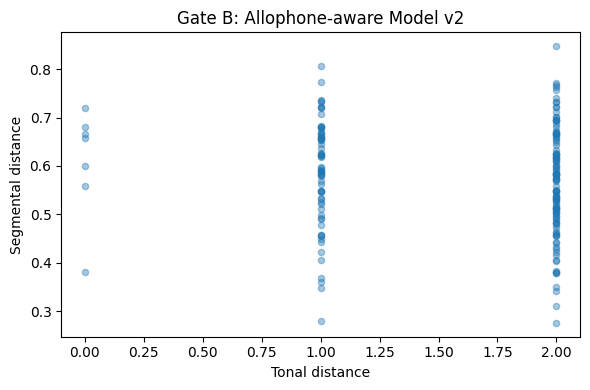


✅ 수정된 분절 RDM 및 Gate B 완료
✅ 기존 v1 파일은 보존됨


In [ ]:
import numpy as np
import pandas as pd
import unicodedata
import json
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ==========================================
# 1. 기존 음운 주석 불러오기
# ==========================================

ann = pd.read_csv(
    ANNOT_DIR / "phonetic_annotations_v1.csv",
    encoding="utf-8-sig"
).sort_values("word").reset_index(drop=True)

assert len(ann) == 20
assert ann["word"].is_unique

# ==========================================
# 2. 중국어 초성 및 운모 분석
# ==========================================

INITIALS = {
    "b": ("bilabial", "stop", 0),
    "p": ("bilabial", "stop", 1),
    "m": ("bilabial", "nasal", 0),
    "f": ("labiodental", "fricative", 0),
    "d": ("alveolar", "stop", 0),
    "t": ("alveolar", "stop", 1),
    "n": ("alveolar", "nasal", 0),
    "l": ("alveolar", "lateral", 0),
    "g": ("velar", "stop", 0),
    "k": ("velar", "stop", 1),
    "h": ("velar", "fricative", 0),
    "j": ("alveolopalatal", "affricate", 0),
    "q": ("alveolopalatal", "affricate", 1),
    "x": ("alveolopalatal", "fricative", 0),
    "zh": ("retroflex", "affricate", 0),
    "ch": ("retroflex", "affricate", 1),
    "sh": ("retroflex", "fricative", 0),
    "r": ("retroflex", "approximant", 0),
    "z": ("alveolar", "affricate", 0),
    "c": ("alveolar", "affricate", 1),
    "s": ("alveolar", "fricative", 0)
}

def remove_tones(s):
    s = unicodedata.normalize("NFD", str(s).lower())
    s = "".join(
        c for c in s
        if c not in "\u0304\u0301\u030c\u0300"
    )
    return unicodedata.normalize("NFC", s)

def parse_syllable(s):
    s = remove_tones(s)

    if s.startswith("y"):
        mapping = {
            "ou": "iou", "ue": "üe",
            "a": "ia", "in": "in",
            "i": "i", "ing": "ing",
            "u": "ü", "uan": "üan",
            "un": "ün", "e": "ie",
            "ao": "iao"
        }
        return "", mapping[s[1:]]

    if s.startswith("w"):
        mapping = {
            "u": "u", "o": "uo",
            "a": "ua", "ai": "uai",
            "ei": "uei", "en": "un"
        }
        return "", mapping[s[1:]]

    onset = next(
        (
            k for k in sorted(
                INITIALS, key=len, reverse=True
            )
            if s.startswith(k)
        ),
        ""
    )

    final = s[len(onset):]

    if onset in {"j", "q", "x"} and final.startswith("u"):
        final = "ü" + final[1:]

    if (
        onset in {"zh", "ch", "sh", "r", "z", "c", "s"}
        and final == "i"
    ):
        final = "apical"

    return onset, final


# ==========================================
# 3. 수정된 운모별 모음 분해
# ==========================================

# 핵심 수정:
# e   -> ɤ  후설
# ie  -> ɛ  전설
# üe  -> ɛ  전설
# ei  -> e  전설
# en  -> ə  중설
# eng -> ə  중설
#
# 문자 하나가 아니라 해당 음운 환경에 따라
# 서로 다른 모음 기호를 부여한다.

FINALS = {
    "a": ("a", ""),
    "o": ("o", ""),
    "e": ("ɤ", ""),
    "i": ("i", ""),
    "u": ("u", ""),
    "ü": ("ü", ""),
    "apical": ("ɿ", ""),

    "ai": ("ai", ""),
    "ei": ("ei", ""),
    "ao": ("au", ""),
    "ou": ("ou", ""),

    "ia": ("ia", ""),
    "ie": ("iɛ", ""),
    "iao": ("iau", ""),
    "iu": ("iou", ""),
    "iou": ("iou", ""),

    "ua": ("ua", ""),
    "uo": ("uo", ""),
    "uai": ("uai", ""),
    "ui": ("uei", ""),
    "uei": ("uei", ""),
    "üe": ("üɛ", ""),

    "an": ("a", "n"),
    "en": ("ə", "n"),
    "ang": ("a", "ng"),
    "eng": ("ə", "ng"),

    "in": ("i", "n"),
    "ing": ("i", "ng"),
    "ong": ("u", "ng"),
    "iong": ("iu", "ng"),

    "ian": ("iɛ", "n"),
    "iang": ("ia", "ng"),
    "uan": ("ua", "n"),
    "un": ("uə", "n"),
    "üan": ("üɛ", "n"),
    "ün": ("ü", "n")
}

# 모음별 도식적인 조음 좌표
# (높이, 전후성, 원순성)
#
# 높이: 0=고, 2=저
# 전후성: 0=전설, 0.5=중설, 1=후설
# 원순성: 0=비원순, 1=원순
#
# 실제 F1/F2 측정치가 아닌 분석용 설정값이다.

VOWELS = {
    "i": (0, 0, 0),
    "u": (0, 1, 1),
    "ü": (0, 0, 1),
    "a": (2, 0.5, 0),
    "o": (1, 1, 1),

    "ɤ": (1, 1, 0),       # 후설 e
    "ɛ": (1.4, 0, 0),     # ie, üe
    "e": (0.8, 0, 0),     # ei
    "ə": (1, 0.5, 0),     # en, eng
    "ɿ": (0.2, 0.5, 0)    # 설첨모음의 단순화 표현
}

# ==========================================
# 4. 자음·모음 거리 계산 함수
# ==========================================

def onset_distance(a, b):
    if a == b:
        return 0.0

    if not a or not b:
        return 1.0

    pa, ma, aa = INITIALS[a]
    pb, mb, ab = INITIALS[b]

    return (
        0.45 * (pa != pb)
        + 0.35 * (ma != mb)
        + 0.20 * (aa != ab)
    )

def vowel_distance(a, b):
    v1 = np.array(VOWELS[a])
    v2 = np.array(VOWELS[b])

    diff = np.abs(v1 - v2)

    cost = (
        diff[0] / 2
        + diff[1]
        + diff[2]
    ) / 3

    if "ɿ" in (a, b) and a != b:
        cost = max(cost, 0.25)

    return float(cost)

def sequence_distance(s1, s2):
    gap = 0.65

    dp = np.zeros(
        (len(s1) + 1, len(s2) + 1)
    )

    dp[:, 0] = np.arange(len(s1) + 1) * gap
    dp[0, :] = np.arange(len(s2) + 1) * gap

    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            dp[i, j] = min(
                dp[i - 1, j] + gap,
                dp[i, j - 1] + gap,
                dp[i - 1, j - 1]
                + vowel_distance(
                    s1[i - 1], s2[j - 1]
                )
            )

    return float(
        dp[-1, -1] / max(len(s1), len(s2))
    )

def final_distance(a, b):
    sa, ca = FINALS[a]
    sb, cb = FINALS[b]

    if ca == cb:
        coda_cost = 0.0
    elif ca and cb:
        coda_cost = 0.5
    else:
        coda_cost = 1.0

    return (
        0.75 * sequence_distance(sa, sb)
        + 0.25 * coda_cost
    )

def syllable_distance(a, b, initial_weight=0.4):
    return (
        initial_weight
        * onset_distance(a[0], b[0])
        + (1 - initial_weight)
        * final_distance(a[1], b[1])
    )


# ==========================================
# 5. 20개 단어의 음운정보 분석
# ==========================================

parsed = []

for row in ann.itertuples(index=False):
    syllables = row.pinyin_candidate.split()

    if len(syllables) != 2:
        raise ValueError(
            f"{row.word}: 2음절 확인 필요"
        )

    item = [
        parse_syllable(s)
        for s in syllables
    ]

    for onset, final in item:
        if final not in FINALS:
            raise ValueError(
                f"등록되지 않은 운모: {final}"
            )

    parsed.append(item)

n = len(parsed)
words = ann["word"].tolist()

tone_values = ann[
    ["tone1", "tone2"]
].to_numpy(dtype=int)

tone_rdm = np.sum(
    tone_values[:, None, :]
    != tone_values[None, :, :],
    axis=2
)

seg_rdm = np.zeros((n, n))
seg_alt = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):

        seg_rdm[i, j] = np.mean([
            syllable_distance(
                parsed[i][k],
                parsed[j][k],
                initial_weight=0.4
            )
            for k in (0, 1)
        ])

        seg_alt[i, j] = np.mean([
            syllable_distance(
                parsed[i][k],
                parsed[j][k],
                initial_weight=0.5
            )
            for k in (0, 1)
        ])

        seg_rdm[j, i] = seg_rdm[i, j]
        seg_alt[j, i] = seg_alt[i, j]

assert np.allclose(seg_rdm, seg_rdm.T)
assert np.allclose(np.diag(seg_rdm), 0)

# ==========================================
# 6. 수정된 RDM 저장
# ==========================================

def save_rdm(array, filename):
    pd.DataFrame(
        array, index=words, columns=words
    ).to_csv(RESULT_DIR / filename)

save_rdm(
    seg_rdm,
    "segmental_rdm_allophone_v2_DRAFT.csv"
)

save_rdm(
    seg_alt,
    "segmental_rdm_allophone_v2_weight50_DRAFT.csv"
)

# 성조 RDM은 변경 없음
save_rdm(
    tone_rdm,
    "tonal_rdm_allophone_v2_DRAFT.csv"
)

# ==========================================
# 7. 기존 분절 RDM과 비교
# ==========================================

old_path = (
    RESULT_DIR / "segmental_rdm_DRAFT.csv"
)

if old_path.exists():

    old = pd.read_csv(
        old_path, index_col=0
    ).loc[words, words].to_numpy()

    difference = np.abs(seg_rdm - old)
    upper = np.triu_indices(n, 1)

    print("===== 기존 모델 대비 변화 =====")
    print(
        "거리값이 바뀐 단어 쌍:",
        int(np.sum(difference[upper] > 1e-9)),
        "/", len(difference[upper])
    )
    print(
        "평균 절대 변화:",
        round(float(difference[upper].mean()), 5)
    )
else:
    print("기존 RDM 파일 없음: 비교 생략")

# ==========================================
# 8. Gate B 재검증
# ==========================================

upper = np.triu_indices(n, 1)

t = tone_rdm[upper]
s = seg_rdm[upper]
s_alt = seg_alt[upper]

r_pearson = pearsonr(t, s).statistic
r_spearman = spearmanr(t, s).statistic

diagnostics = pd.DataFrame([{
    "n_words": n,
    "n_pairs": len(t),
    "segment_unique_4dp": len(
        np.unique(np.round(s, 4))
    ),
    "segment_max_fraction": float(
        np.mean(np.isclose(s, s.max()))
    ),
    "tone_segment_pearson": r_pearson,
    "tone_segment_spearman": r_spearman,
    "vif": 1 / (1 - r_pearson**2),
    "weight_sensitivity_spearman":
        spearmanr(s, s_alt).statistic
}])

diagnostics.to_csv(
    RESULT_DIR /
    "gateB_allophone_v2_DRAFT.csv",
    index=False
)

print("\n===== 수정된 Gate B 결과 =====")
display(diagnostics.T)

# ==========================================
# 9. 수정된 모델 시각화
# ==========================================

plt.figure(figsize=(6, 4))

plt.scatter(
    t, s,
    alpha=0.4,
    s=20
)

plt.xlabel("Tonal distance")
plt.ylabel("Segmental distance")
plt.title("Gate B: Allophone-aware Model v2")
plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "gateB_allophone_v2_DRAFT.png",
    dpi=160
)

plt.show()

# ==========================================
# 10. 모델 설정 기록
# ==========================================

settings = {
    "version": "v2_allophone",
    "vowel_e_back": "ɤ",
    "vowel_e_front_open": "ɛ",
    "vowel_e_front_close": "e",
    "vowel_e_central": "ə",
    "initial_weight": 0.4,
    "final_weight": 0.6,
    "caveat": (
        "Approximate context-sensitive phonetic "
        "feature distances, not measured formants. "
        "Stimulus annotations remain unverified."
    )
}

with open(
    RESULT_DIR /
    "segmental_model_v2_settings.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        settings,
        f,
        ensure_ascii=False,
        indent=2
    )

print("\n✅ 수정된 분절 RDM 및 Gate B 완료")
print("✅ 기존 v1 파일은 보존됨")

✅ 신경 특징과 음운 RDM 정렬 완료
신경 RDM 계산 중: Vocalized
✅ Vocalized: 신경 RDM 저장 완료
신경 RDM 계산 중: Mimed
✅ Mimed: 신경 RDM 저장 완료
신경 RDM 계산 중: Imagined
✅ Imagined: 신경 RDM 저장 완료

===== 다중회귀 RSA 예비 결과 =====


,mode,beta_tone,beta_segmental,intercept,r2_in_sample,r2_leave_word_out,neural_distance_mean,neural_distance_std,negative_distance_fraction
0,Vocalized,0.000245,0.000518,0.006964,0.007134,-0.054978,0.006964,0.006500,0.105263
1,Mimed,-0.000152,0.000176,0.003799,0.004750,-0.056108,0.003799,0.003550,0.110526
2,Imagined,-0.000041,-0.000236,-0.000064,0.017760,-0.070113,-0.000064,0.001764,0.536842


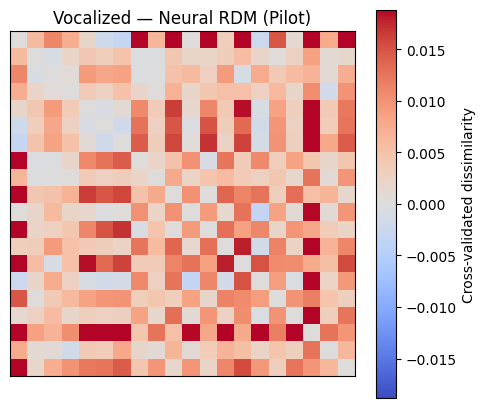

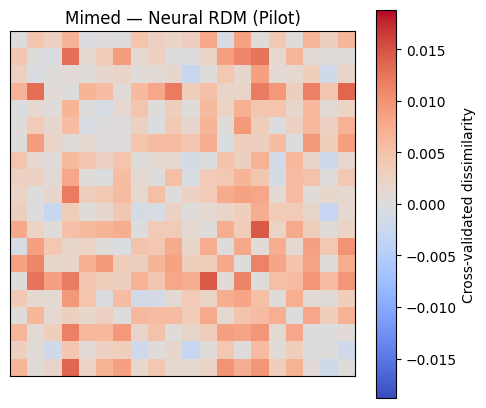

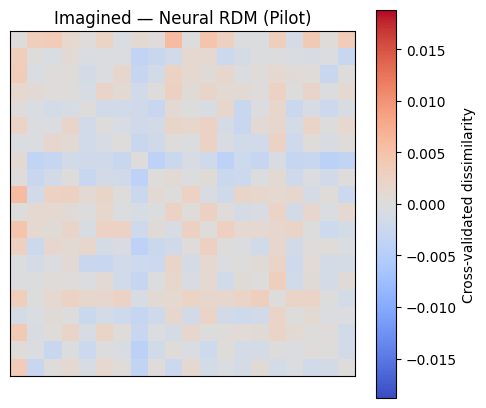

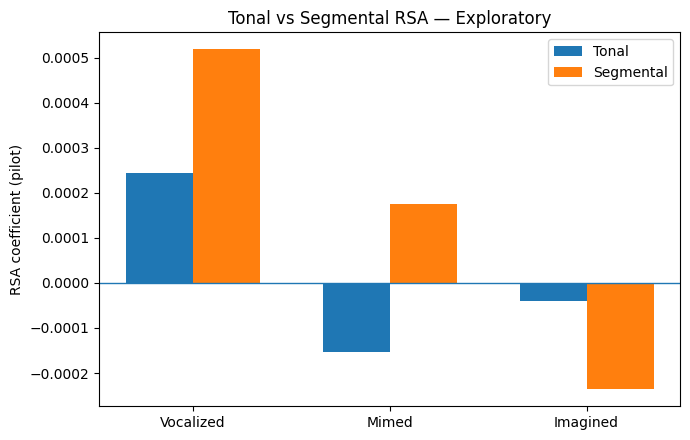


✅ 15~17단계 완료
✅ 신경 RDM 및 RSA 결과 공유 Drive 저장
✅ 기존 신경 데이터 재다운로드 없음


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 15. 입력 데이터 불러오기 및 검증
# ======================================================

FEATURE_PATH = (
    RESULT_DIR / "gateA_features_500ms.npz"
)

TONE_PATH = (
    RESULT_DIR / "tonal_rdm_allophone_v2_DRAFT.csv"
)

SEG_PATH = (
    RESULT_DIR / "segmental_rdm_allophone_v2_DRAFT.csv"
)

MODES = ["Vocalized", "Mimed", "Imagined"]
N_SPLITS = 200
SEED = 20261009

with np.load(FEATURE_PATH, allow_pickle=False) as f:
    trial_modes = f["modes"]
    trial_words = f["words"]
    trial_reps = f["reps"]
    features = f["features"]

assert features.shape == (357, 660)
assert np.isfinite(features).all()

# 성조 RDM의 단어 순서를 기준으로 통일
tone_df = pd.read_csv(TONE_PATH, index_col=0)
seg_df = pd.read_csv(SEG_PATH, index_col=0)

words = sorted(tone_df.index.tolist())

assert len(words) == 20
assert set(seg_df.index) == set(words)
assert set(tone_df.columns) == set(words)
assert set(seg_df.columns) == set(words)

T = tone_df.loc[words, words].to_numpy(
    dtype=float
)

S = seg_df.loc[words, words].to_numpy(
    dtype=float
)

for name, matrix in [("Tone", T), ("Segmental", S)]:
    assert matrix.shape == (20, 20)
    assert np.isfinite(matrix).all()
    assert np.allclose(matrix, matrix.T)
    assert np.allclose(np.diag(matrix), 0)

print("✅ 신경 특징과 음운 RDM 정렬 완료")

# 중복 없는 단어 쌍 190개
upper = np.triu_indices(20, k=1)

tone_vector = T[upper]
seg_vector = S[upper]

# 예측변수의 척도 통일
def standardize(x):
    sd = x.std()
    if sd <= 0:
        raise ValueError("예측변수의 분산이 0입니다.")
    return (x - x.mean()) / sd

X = np.column_stack([
    np.ones(190),
    standardize(tone_vector),
    standardize(seg_vector)
])

assert np.linalg.matrix_rank(X) == 3


# ======================================================
# 16. 교차검증 신경 RDM 구축
# ======================================================

def calculate_neural_rdm(mode):

    selected_words = set(
        trial_words[trial_modes == mode]
    )

    if selected_words != set(words):
        raise ValueError(
            f"{mode}: 단어 목록이 일치하지 않습니다."
        )

    # 단어별 반복 시행 인덱스
    groups = []

    for word in words:

        idx = np.where(
            (trial_modes == mode) &
            (trial_words == word)
        )[0]

        idx = idx[
            np.argsort(trial_reps[idx])
        ]

        if len(idx) < 4:
            raise ValueError(
                f"{mode}, {word}: 시행 부족"
            )

        groups.append(idx)

    rng = np.random.default_rng(SEED)

    rdm_sum = np.zeros((20, 20))

    for split in range(N_SPLITS):

        A = []
        B = []

        for idx in groups:

            shuffled = rng.permutation(idx)

            n_train = len(idx) // 2

            A.append(
                features[
                    shuffled[:n_train]
                ].mean(axis=0)
            )

            B.append(
                features[
                    shuffled[n_train:]
                ].mean(axis=0)
            )

        A = np.stack(A)
        B = np.stack(B)

        # 각 단어 쌍의 신경 패턴 차이
        diff_A = A[:, None, :] - A[None, :, :]
        diff_B = B[:, None, :] - B[None, :, :]

        # 교차검증된 제곱 유클리드 거리
        distances = np.einsum(
            "ijk,ijk->ij",
            diff_A,
            diff_B
        ) / features.shape[1]

        rdm_sum += distances

    rdm = rdm_sum / N_SPLITS

    np.fill_diagonal(rdm, 0)

    assert np.allclose(rdm, rdm.T)
    assert np.isfinite(rdm).all()

    return rdm


neural_rdms = {}

for mode in MODES:

    save_path = (
        RESULT_DIR /
        f"neural_rdm_cv500_v2_{mode}.csv"
    )

    if save_path.exists():

        saved = pd.read_csv(
            save_path, index_col=0
        )

        if (
            set(saved.index) == set(words)
            and set(saved.columns) == set(words)
        ):
            rdm = saved.loc[
                words, words
            ].to_numpy(dtype=float)

            print(f"✅ {mode}: 기존 신경 RDM 재사용")

        else:
            raise ValueError(
                f"{mode}: 기존 파일의 단어 목록 불일치"
            )

    else:

        print(f"신경 RDM 계산 중: {mode}")

        rdm = calculate_neural_rdm(mode)

        pd.DataFrame(
            rdm,
            index=words,
            columns=words
        ).to_csv(save_path)

        print(f"✅ {mode}: 신경 RDM 저장 완료")

    assert rdm.shape == (20, 20)
    assert np.isfinite(rdm).all()
    assert np.allclose(rdm, rdm.T)

    neural_rdms[mode] = rdm


# ======================================================
# 17-A. 다중회귀 RSA
# ======================================================

def fit_ols(x, y):
    return np.linalg.lstsq(
        x, y, rcond=None
    )[0]


# ======================================================
# 17-B. Leave-one-word-out 검증
#
# 한 단어를 제외한 19개 단어 쌍으로 회귀계수 추정
# 제외한 단어와 나머지 단어 사이의 거리를 예측
# ======================================================

pair_i, pair_j = upper

def leave_word_out_prediction(y):

    prediction_sum = np.zeros(len(y))
    prediction_count = np.zeros(len(y))

    for held_word in range(20):

        test_mask = (
            (pair_i == held_word) |
            (pair_j == held_word)
        )

        train_mask = ~test_mask

        b = fit_ols(
            X[train_mask],
            y[train_mask]
        )

        prediction_sum[test_mask] += (
            X[test_mask] @ b
        )

        prediction_count[test_mask] += 1

    # 각 단어 쌍은 양쪽 단어를 제외하는
    # 두 번의 평가에 등장
    assert np.all(prediction_count == 2)

    return prediction_sum / prediction_count


results = []

for mode in MODES:

    y = neural_rdms[mode][upper]

    # 주 예비 회귀분석
    beta = fit_ols(X, y)

    y_hat = X @ beta

    total_ss = np.sum(
        (y - y.mean())**2
    )

    if total_ss <= 0:
        raise ValueError(
            f"{mode}: 신경 거리의 분산이 0입니다."
        )

    r2 = 1 - (
        np.sum((y - y_hat)**2) / total_ss
    )

    # 단어 제외 교차검증
    loo_pred = leave_word_out_prediction(y)

    loo_r2 = 1 - (
        np.sum((y - loo_pred)**2) / total_ss
    )

    results.append({
        "mode": mode,
        "beta_tone": float(beta[1]),
        "beta_segmental": float(beta[2]),
        "intercept": float(beta[0]),
        "r2_in_sample": float(r2),
        "r2_leave_word_out": float(loo_r2),
        "neural_distance_mean": float(y.mean()),
        "neural_distance_std": float(y.std()),
        "negative_distance_fraction": float(
            np.mean(y < 0)
        )
    })

summary = pd.DataFrame(results)

SUMMARY_PATH = (
    RESULT_DIR / "rsa_pilot_descriptive_v2.csv"
)

summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n===== 다중회귀 RSA 예비 결과 =====")
display(summary.round(6))


# ======================================================
# 17-C. 세 조건의 신경 RDM 시각화
# ======================================================

all_values = np.concatenate([
    neural_rdms[m][upper]
    for m in MODES
])

limit = np.percentile(
    np.abs(all_values), 98
)

if limit <= 0:
    limit = 1

for mode in MODES:

    plt.figure(figsize=(5, 4.3))

    plt.imshow(
        neural_rdms[mode],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit
    )

    plt.title(f"{mode} — Neural RDM (Pilot)")
    plt.colorbar(label="Cross-validated dissimilarity")

    plt.xticks([])
    plt.yticks([])

    plt.tight_layout()

    plt.savefig(
        RESULT_DIR /
        f"neural_rdm_pilot_{mode}.png",
        dpi=160
    )

    plt.show()
    plt.close()


# ======================================================
# 17-D. RSA 회귀계수 시각화
# ======================================================

x = np.arange(len(MODES))
width = 0.34

plt.figure(figsize=(7, 4.5))

plt.bar(
    x - width / 2,
    summary["beta_tone"],
    width,
    label="Tonal"
)

plt.bar(
    x + width / 2,
    summary["beta_segmental"],
    width,
    label="Segmental"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, MODES)

plt.ylabel("RSA coefficient (pilot)")
plt.title("Tonal vs Segmental RSA — Exploratory")
plt.legend()

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "rsa_coefficients_pilot_v2.png",
    dpi=160
)

plt.show()
plt.close()


# ======================================================
# 17-E. 분석 설정 저장
# ======================================================

settings = {
    "status": "exploratory_draft",
    "feature": "HGA",
    "n_electrodes": 110,
    "electrode_selection": "all",
    "time_window_ms": 500,
    "feature_dimensions": 660,
    "neural_distance":
        "cross-validated squared Euclidean",
    "number_of_splits": N_SPLITS,
    "seed": SEED,
    "rsa_predictors": [
        "tone_v2_DRAFT",
        "segmental_allophone_v2_DRAFT"
    ],
    "predictor_normalization":
        "z-scored over 190 word pairs",
    "neural_response_normalization":
        "no additional z-scoring",
    "inference": (
        "Descriptive only. No valid "
        "feature-level hypothesis tests yet."
    ),
    "limitations": [
        "MNI mapping unresolved",
        "visual stimulus confounding",
        "phonetic annotation draft",
        "single participant"
    ]
}

with open(
    RESULT_DIR / "rsa_pilot_v2_settings.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        settings, f,
        ensure_ascii=False,
        indent=2
    )

print("\n✅ 15~17단계 완료")
print("✅ 신경 RDM 및 RSA 결과 공유 Drive 저장")
print("✅ 기존 신경 데이터 재다운로드 없음")


검증 중: Vocalized


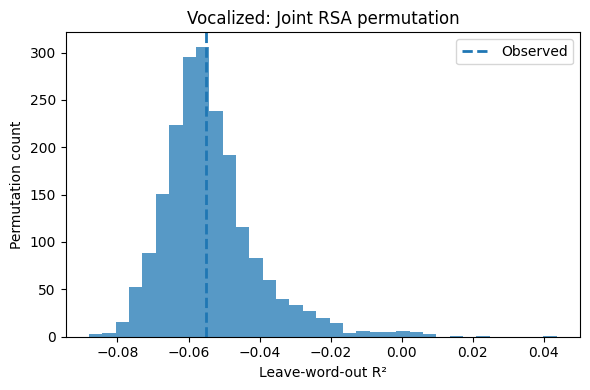

✅ Vocalized 완료

검증 중: Mimed


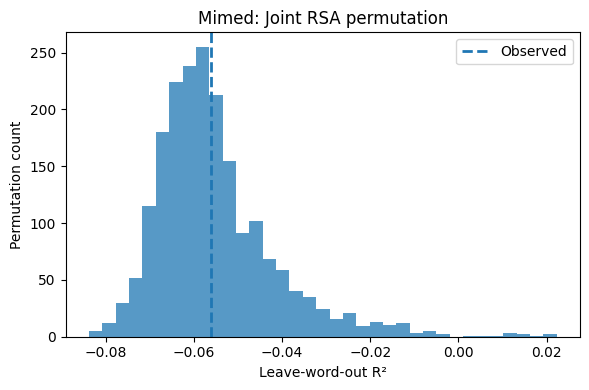

✅ Mimed 완료

검증 중: Imagined


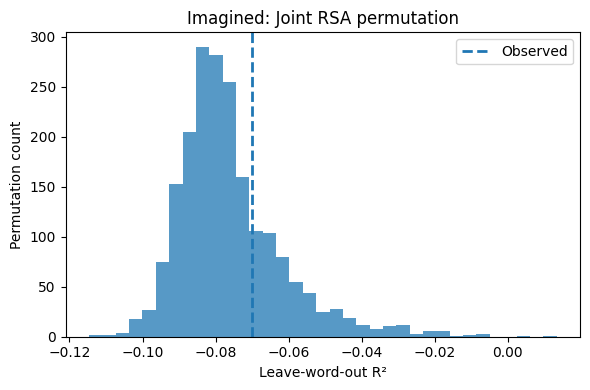

✅ Imagined 완료

✅ 결과 저장 완료

===== RSA 전체 모델 순열검정 =====


,mode,observed_r2,observed_cv_r2,p_joint_r2,p_joint_cv_r2,beta_tone,beta_segmental,null_cv_95th,p_joint_cv_holm
0,Vocalized,0.007134,-0.054978,0.513743,0.460770,0.000245,0.000518,-0.027999,0.862569
1,Mimed,0.004750,-0.056108,0.636182,0.431284,-0.000152,0.000176,-0.028894,0.862569
2,Imagined,0.017760,-0.070113,0.207896,0.255372,-0.000041,-0.000236,-0.047293,0.766117



===== 계수 안정성 검사 =====


,mode,feature,original_beta,jackknife_min,jackknife_max,same_sign_count,n_exclusions
0,Vocalized,tone,0.000245,-0.000058,0.000417,19,20
1,Vocalized,segmental,0.000518,0.000141,0.000890,20,20
2,Mimed,tone,-0.000152,-0.000297,-0.000027,20,20
3,Mimed,segmental,0.000176,0.000070,0.000324,20,20
4,Imagined,tone,-0.000041,-0.000144,0.000038,15,20
5,Imagined,segmental,-0.000236,-0.000299,-0.000143,20,20



✅ 18~19단계 완료
기존 RDM과 신경 데이터는 변경하지 않았습니다.


In [ ]:
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 설정
# ============================================

MODES = ["Vocalized", "Mimed", "Imagined"]
N_PERM = 2000
SEED = 20261009

TONE_PATH = (
    RESULT_DIR / "tonal_rdm_allophone_v2_DRAFT.csv"
)
SEG_PATH = (
    RESULT_DIR / "segmental_rdm_allophone_v2_DRAFT.csv"
)

SUMMARY_PATH = RESULT_DIR / "rsa_validation_v2.csv"
JACK_PATH = RESULT_DIR / "rsa_jackknife_v2.csv"
META_PATH = RESULT_DIR / "rsa_validation_v2_meta.json"

NEURAL_PATHS = {
    mode: RESULT_DIR /
    f"neural_rdm_cv500_v2_{mode}.csv"
    for mode in MODES
}

INPUT_PATHS = [
    TONE_PATH, SEG_PATH,
    *NEURAL_PATHS.values()
]

for path in INPUT_PATHS:
    if not path.exists():
        raise FileNotFoundError(path)

# 입력 파일이 바뀌면 자동으로 재계산
signatures = {
    path.name:
    hashlib.sha256(path.read_bytes()).hexdigest()
    for path in INPUT_PATHS
}

settings = {
    "n_permutations": N_PERM,
    "seed": SEED,
    "input_hashes": signatures
}

# ============================================
# 기존 결과 재사용
# ============================================

reuse = (
    SUMMARY_PATH.exists()
    and JACK_PATH.exists()
    and META_PATH.exists()
)

if reuse:
    try:
        saved_settings = json.loads(
            META_PATH.read_text(encoding="utf-8")
        )
        reuse = saved_settings == settings
    except Exception:
        reuse = False

if reuse:

    print("✅ 기존 18~19단계 결과 재사용")

    summary = pd.read_csv(SUMMARY_PATH)
    jackknife = pd.read_csv(JACK_PATH)

else:

    # ========================================
    # 18-A. 음운 모델 불러오기
    # ========================================

    tone_df = pd.read_csv(
        TONE_PATH, index_col=0
    )

    seg_df = pd.read_csv(
        SEG_PATH, index_col=0
    )

    words = sorted(tone_df.index.tolist())
    n = len(words)

    assert n == 20
    assert set(tone_df.columns) == set(words)
    assert set(seg_df.index) == set(words)
    assert set(seg_df.columns) == set(words)

    T = tone_df.loc[
        words, words
    ].to_numpy(dtype=float)

    S = seg_df.loc[
        words, words
    ].to_numpy(dtype=float)

    upper = np.triu_indices(n, 1)

    def zscore(x):
        if x.std() <= 0:
            raise ValueError("예측변수 분산이 0")
        return (x - x.mean()) / x.std()

    X = np.column_stack([
        np.ones(len(upper[0])),
        zscore(T[upper]),
        zscore(S[upper])
    ])

    assert np.linalg.matrix_rank(X) == 3

    # ========================================
    # 18-B. 회귀 및 단어 제외 예측 함수
    # ========================================

    pair_i, pair_j = upper

    # 반복 실행 속도를 위해 회귀 행렬을 미리 계산
    full_pinv = np.linalg.pinv(X)

    folds = []

    for held_word in range(n):

        test = (
            (pair_i == held_word) |
            (pair_j == held_word)
        )

        train = ~test

        folds.append((
            train,
            test,
            np.linalg.pinv(X[train])
        ))

    def calculate_fit(y):

        y = np.asarray(y, dtype=float)

        beta = full_pinv @ y
        predicted = X @ beta

        total_ss = np.sum(
            (y - y.mean()) ** 2
        )

        if total_ss <= 0:
            raise ValueError(
                "신경 거리의 분산이 0입니다."
            )

        r2 = 1 - np.sum(
            (y - predicted) ** 2
        ) / total_ss

        predictions = np.zeros_like(y)
        counts = np.zeros_like(y)

        for train, test, pinv_train in folds:

            b = pinv_train @ y[train]

            predictions[test] += X[test] @ b
            counts[test] += 1

        assert np.all(counts == 2)

        predictions /= counts

        cv_r2 = 1 - np.sum(
            (y - predictions) ** 2
        ) / total_ss

        return beta, r2, cv_r2

    # ========================================
    # 18-C. 단어 단위 순열검정
    # ========================================

    rng = np.random.default_rng(SEED)

    results = []
    jackknife_rows = []

    # 세 조건에 대해 동일한 순열 목록 사용
    permutations = [
        rng.permutation(n)
        for _ in range(N_PERM)
    ]

    for mode in MODES:

        print(f"\n검증 중: {mode}")

        neural_df = pd.read_csv(
            NEURAL_PATHS[mode], index_col=0
        )

        assert set(neural_df.index) == set(words)
        assert set(neural_df.columns) == set(words)

        neural = neural_df.loc[
            words, words
        ].to_numpy(dtype=float)

        assert neural.shape == (20, 20)
        assert np.isfinite(neural).all()
        assert np.allclose(neural, neural.T)

        y = neural[upper]

        beta, observed_r2, observed_cv = (
            calculate_fit(y)
        )

        null_r2 = []
        null_cv = []

        for permutation in permutations:

            # 단어의 행과 열을 함께 재배열
            randomized_neural = neural[
                np.ix_(permutation, permutation)
            ]

            randomized_y = randomized_neural[upper]

            _, r2_null, cv_null = calculate_fit(
                randomized_y
            )

            null_r2.append(r2_null)
            null_cv.append(cv_null)

        null_r2 = np.array(null_r2)
        null_cv = np.array(null_cv)

        p_r2 = (
            np.sum(null_r2 >= observed_r2) + 1
        ) / (N_PERM + 1)

        p_cv = (
            np.sum(null_cv >= observed_cv) + 1
        ) / (N_PERM + 1)

        # ====================================
        # 19. 단어 제외 계수 안정성
        # ====================================

        for held_word, (
            train, test, pinv_train
        ) in enumerate(folds):

            b = pinv_train @ y[train]

            jackknife_rows.append({
                "mode": mode,
                "excluded_word": words[held_word],
                "beta_tone": float(b[1]),
                "beta_segmental": float(b[2])
            })

        results.append({
            "mode": mode,
            "observed_r2": observed_r2,
            "observed_cv_r2": observed_cv,
            "p_joint_r2": p_r2,
            "p_joint_cv_r2": p_cv,
            "beta_tone": float(beta[1]),
            "beta_segmental": float(beta[2]),
            "null_cv_95th": float(
                np.percentile(null_cv, 95)
            )
        })

        # 순열분포 그림
        plt.figure(figsize=(6, 4))

        plt.hist(
            null_cv,
            bins=35,
            alpha=0.75
        )

        plt.axvline(
            observed_cv,
            linestyle="--",
            linewidth=2,
            label="Observed"
        )

        plt.xlabel("Leave-word-out R²")
        plt.ylabel("Permutation count")
        plt.title(f"{mode}: Joint RSA permutation")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            RESULT_DIR /
            f"rsa_permutation_{mode}_v2.png",
            dpi=160
        )

        plt.show()
        plt.close()

        print(f"✅ {mode} 완료")

    summary = pd.DataFrame(results)
    jackknife = pd.DataFrame(jackknife_rows)

    # 세 조건의 교차검증 검정에 Holm 보정
    pvals = summary["p_joint_cv_r2"].to_numpy()
    order = np.argsort(pvals)

    corrected = np.empty(len(pvals))
    running_max = 0.0

    for rank, idx in enumerate(order):
        adjusted = min(
            1.0,
            (len(pvals) - rank) * pvals[idx]
        )
        running_max = max(
            running_max, adjusted
        )
        corrected[idx] = running_max

    summary["p_joint_cv_holm"] = corrected

    summary.to_csv(
        SUMMARY_PATH, index=False
    )

    jackknife.to_csv(
        JACK_PATH, index=False
    )

    META_PATH.write_text(
        json.dumps(
            settings, indent=2, ensure_ascii=False
        ),
        encoding="utf-8"
    )

    print("\n✅ 결과 저장 완료")

# ============================================
# 결과 출력
# ============================================

print("\n===== RSA 전체 모델 순열검정 =====")

display(summary.round(6))

print("\n===== 계수 안정성 검사 =====")

stability = []

for mode in MODES:

    sub = jackknife[
        jackknife["mode"] == mode
    ]

    original = summary[
        summary["mode"] == mode
    ].iloc[0]

    for feature in ["tone", "segmental"]:

        column = f"beta_{feature}"

        stability.append({
            "mode": mode,
            "feature": feature,
            "original_beta": original[column],
            "jackknife_min": sub[column].min(),
            "jackknife_max": sub[column].max(),
            "same_sign_count": int(
                np.sum(
                    np.sign(sub[column])
                    == np.sign(original[column])
                )
            ),
            "n_exclusions": len(sub)
        })

stability_df = pd.DataFrame(stability)

display(stability_df.round(6))

stability_df.to_csv(
    RESULT_DIR / "rsa_coefficient_stability_v2.csv",
    index=False
)

print("\n✅ 18~19단계 완료")
print("기존 RDM과 신경 데이터는 변경하지 않았습니다.")

357개 시행에서 6종류의 특징 추출 중...
✅ 6종류 신경 특징 공유 Drive 저장
분석 중: Vocalized, HGA, 250ms
분석 중: Mimed, HGA, 250ms
분석 중: Imagined, HGA, 250ms
분석 중: Vocalized, HGA, 500ms
분석 중: Mimed, HGA, 500ms
분석 중: Imagined, HGA, 500ms
분석 중: Vocalized, HGA, 750ms
분석 중: Mimed, HGA, 750ms
분석 중: Imagined, HGA, 750ms
분석 중: Vocalized, LFS, 250ms
분석 중: Mimed, LFS, 250ms
분석 중: Imagined, LFS, 250ms
분석 중: Vocalized, LFS, 500ms
분석 중: Mimed, LFS, 500ms
분석 중: Imagined, LFS, 500ms
분석 중: Vocalized, LFS, 750ms
분석 중: Mimed, LFS, 750ms
분석 중: Imagined, LFS, 750ms
✅ 민감도 분석 결과 저장 완료

===== 18개 조건: 주요 분석 결과 =====


,mode,band,window_ms,mean_accuracy,mean_reliability,r2_in_sample,r2_leave_word_out
0,Vocalized,HGA,250,0.24725,0.12226,0.01046,-0.00975
1,Mimed,HGA,250,0.21100,0.08405,0.00509,-0.01622
2,Imagined,HGA,250,0.03500,0.00663,0.01308,-0.01400
3,Vocalized,HGA,500,0.21975,0.15149,0.00713,-0.01255
4,Mimed,HGA,500,0.18175,0.10488,0.00504,-0.01191
5,Imagined,HGA,500,0.04875,-0.00068,0.01738,-0.00543
6,Vocalized,HGA,750,0.22475,0.18001,0.00983,-0.01289
7,Mimed,HGA,750,0.16600,0.11606,0.00179,-0.01480
8,Imagined,HGA,750,0.05100,0.01295,0.01423,-0.01204
9,Vocalized,LFS,250,0.23050,0.10736,0.00453,-0.01895



===== 성조·분절 계수 =====


,mode,band,window_ms,beta_tone,beta_segmental
0,Vocalized,HGA,250,0.000466,0.000679
1,Mimed,HGA,250,-0.000313,0.000101
2,Imagined,HGA,250,-0.000120,-0.000221
3,Vocalized,HGA,500,0.000245,0.000518
4,Mimed,HGA,500,-0.000165,0.000175
5,Imagined,HGA,500,-0.000044,-0.000231
6,Vocalized,HGA,750,0.000370,0.000446
7,Mimed,HGA,750,-0.000124,0.000046
8,Imagined,HGA,750,-0.000036,-0.000161
9,Vocalized,LFS,250,-0.001630,0.002251


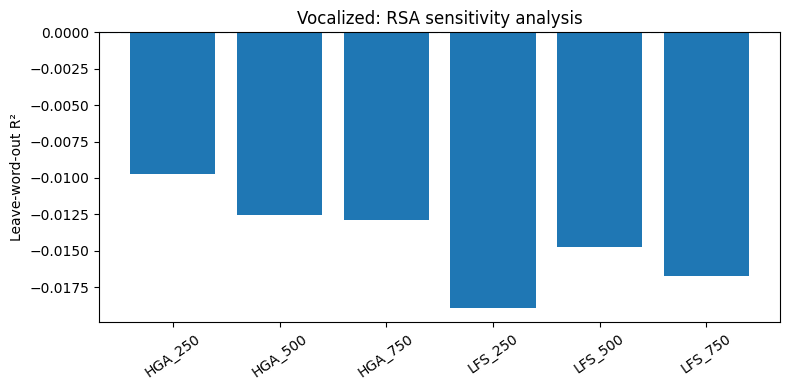

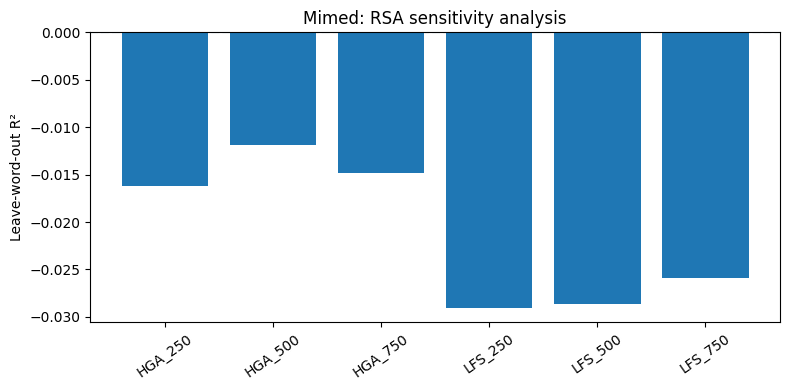

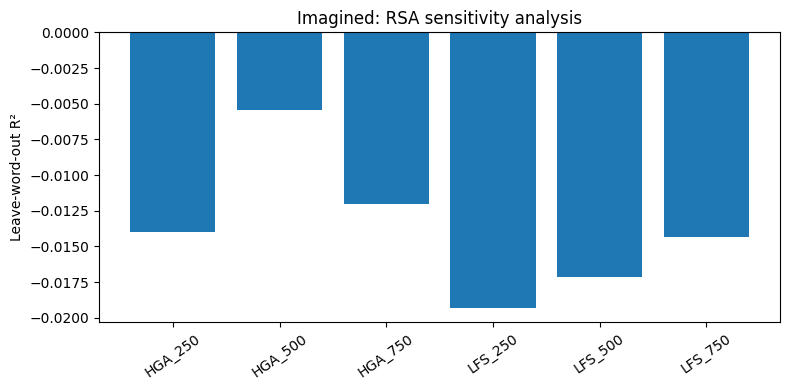


✅ 20~21단계 완료
✅ ZIP 재다운로드 없음
✅ 결과 공유 Drive 저장
※ 탐색적 민감도 분석: 확증적 p값 아님


In [ ]:
import io
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# 설정
# ==================================================

MODES = ["Vocalized", "Mimed", "Imagined"]
BANDS = ["HGA", "LFS"]
WINDOWS = [250, 500, 750]

N_SPLITS = 200
SEED = 20261009

CACHE = RESULT_DIR / "sensitivity_features_v1.npz"
SUMMARY = RESULT_DIR / "sensitivity_summary_v1.csv"

# ==================================================
# 1. 음운 RDM 불러오기
# ==================================================

tone_df = pd.read_csv(
    RESULT_DIR / "tonal_rdm_allophone_v2_DRAFT.csv",
    index_col=0
)

seg_df = pd.read_csv(
    RESULT_DIR / "segmental_rdm_allophone_v2_DRAFT.csv",
    index_col=0
)

words = sorted(tone_df.index.tolist())

assert len(words) == 20
assert set(tone_df.columns) == set(words)
assert set(seg_df.index) == set(words)
assert set(seg_df.columns) == set(words)

T = tone_df.loc[words, words].to_numpy(float)
S = seg_df.loc[words, words].to_numpy(float)

upper = np.triu_indices(20, 1)
pair_i, pair_j = upper

def zscore(x):
    std = x.std()
    if std <= 0:
        raise ValueError("예측변수 분산이 0입니다.")
    return (x - x.mean()) / std

X = np.column_stack([
    np.ones(190),
    zscore(T[upper]),
    zscore(S[upper])
])

assert np.linalg.matrix_rank(X) == 3

# ==================================================
# 2. 6가지 신경 특징 추출 또는 캐시 재사용
# ==================================================

feature_keys = [
    f"{band}_{window}"
    for band in BANDS
    for window in WINDOWS
]

if CACHE.exists():

    print("✅ 기존 신경 특징 재사용")

    with np.load(CACHE, allow_pickle=False) as data:
        trial_modes = data["modes"]
        trial_words = data["words"]
        trial_reps = data["reps"]
        feature_sets = {
            key: data[key]
            for key in feature_keys
        }

else:

    print("357개 시행에서 6종류의 특징 추출 중...")

    metadata = []
    collected = {
        key: [] for key in feature_keys
    }

    for mode in MODES:

        zip_path = DATA_DIR / (
            f"Processed_sEEG_{mode}_Word.zip"
        )

        with zipfile.ZipFile(zip_path) as z:

            files = sorted(
                n for n in z.namelist()
                if n.endswith(".npy")
            )

            for filename in files:

                name = Path(filename).stem

                match = re.fullmatch(
                    rf"{mode}_(.+)_(\d+)", name
                )

                if match is None:
                    raise ValueError(filename)

                signal = np.load(
                    io.BytesIO(z.read(filename)),
                    allow_pickle=False
                )

                if signal.shape != (600, 220):
                    raise ValueError(
                        f"배열 크기 오류: {filename}"
                    )

                metadata.append((
                    mode,
                    match.group(1),
                    int(match.group(2))
                ))

                for band in BANDS:

                    if band == "HGA":
                        x = signal[:, :110]
                    else:
                        x = signal[:, 110:]

                    for window in WINDOWS:

                        samples = window // 5

                        vector = (
                            x.reshape(
                                600 // samples,
                                samples,
                                110
                            )
                            .mean(axis=1)
                            .reshape(-1)
                        )

                        collected[
                            f"{band}_{window}"
                        ].append(vector)

    trial_modes = np.array(
        [m[0] for m in metadata]
    )
    trial_words = np.array(
        [m[1] for m in metadata]
    )
    trial_reps = np.array(
        [m[2] for m in metadata]
    )

    feature_sets = {
        key: np.stack(collected[key])
        for key in feature_keys
    }

    np.savez_compressed(
        CACHE,
        modes=trial_modes,
        words=trial_words,
        reps=trial_reps,
        **feature_sets
    )

    print("✅ 6종류 신경 특징 공유 Drive 저장")

assert len(trial_modes) == 357

for key, features in feature_sets.items():
    assert features.shape[0] == 357
    assert np.isfinite(features).all()

# ==================================================
# 3. 반복 시행 분할 생성
# 조건마다 같은 분할을 6종류의 특징에 재사용
# ==================================================

split_assignments = {}

for mode_index, mode in enumerate(MODES):

    groups = []

    for word in words:

        idx = np.where(
            (trial_modes == mode)
            & (trial_words == word)
        )[0]

        idx = idx[np.argsort(trial_reps[idx])]

        if len(idx) < 5:
            raise ValueError(
                f"{mode}: {word} 시행 부족"
            )

        groups.append(idx)

    rng = np.random.default_rng(
        SEED + mode_index
    )

    assignments = []

    for _ in range(N_SPLITS):

        train_idx = []
        test_idx = []

        for idx in groups:

            shuffled = rng.permutation(idx)
            midpoint = len(idx) // 2

            train_idx.append(shuffled[:midpoint])
            test_idx.append(shuffled[midpoint:])

        assignments.append(
            (train_idx, test_idx)
        )

    split_assignments[mode] = assignments

# ==================================================
# 4. 교차검증 신경 RDM 및 단어 재현성
# ==================================================

def compute_rdm_and_reliability(features, mode):

    rdm_sum = np.zeros((20, 20))
    accuracy_list = []
    reliability_list = []

    for train_idx, test_idx in split_assignments[mode]:

        A = np.stack([
            features[idx].mean(axis=0)
            for idx in train_idx
        ])

        B = np.stack([
            features[idx].mean(axis=0)
            for idx in test_idx
        ])

        # 교차검증 제곱 유클리드 거리
        cross = A @ B.T
        diagonal = np.diag(cross)

        distances = (
            diagonal[:, None]
            + diagonal[None, :]
            - cross
            - cross.T
        ) / features.shape[1]

        rdm_sum += distances

        # 단어 분류 성능
        An = A / np.maximum(
            np.linalg.norm(A, axis=1, keepdims=True),
            1e-12
        )

        Bn = B / np.maximum(
            np.linalg.norm(B, axis=1, keepdims=True),
            1e-12
        )

        sim = Bn @ An.T

        accuracy_list.append(
            np.mean(
                np.argmax(sim, axis=1)
                == np.arange(20)
            )
        )

        same = np.trace(sim) / 20

        different = (
            sim.sum() - np.trace(sim)
        ) / (20 * 19)

        reliability_list.append(
            same - different
        )

    rdm = rdm_sum / N_SPLITS
    rdm = (rdm + rdm.T) / 2
    np.fill_diagonal(rdm, 0)

    return (
        rdm,
        float(np.mean(accuracy_list)),
        float(np.mean(reliability_list))
    )

# ==================================================
# 5. RSA 및 단어 제외 예측
# ==================================================

def fit_rsa(rdm):

    y = rdm[upper]

    beta = np.linalg.lstsq(
        X, y, rcond=None
    )[0]

    prediction = X @ beta

    ss = np.sum((y - y.mean()) ** 2)

    if ss <= 1e-20:
        raise ValueError("신경 거리 분산이 거의 0")

    r2 = 1 - (
        np.sum((y - prediction) ** 2) / ss
    )

    # 단어 하나를 제외해 모형을 학습
    # 20회 평가에서 시험셋 예측과
    # 학습셋 평균 기준 예측을 비교
    model_error = 0.0
    baseline_error = 0.0

    for held_word in range(20):

        test = (
            (pair_i == held_word)
            | (pair_j == held_word)
        )

        train = ~test

        b = np.linalg.lstsq(
            X[train], y[train], rcond=None
        )[0]

        predicted = X[test] @ b
        baseline = y[train].mean()

        model_error += np.sum(
            (y[test] - predicted) ** 2
        )

        baseline_error += np.sum(
            (y[test] - baseline) ** 2
        )

    cv_r2 = (
        1 - model_error / baseline_error
        if baseline_error > 0
        else np.nan
    )

    return beta, float(r2), float(cv_r2)

# ==================================================
# 6. 18가지 조합 분석
# ==================================================

if SUMMARY.exists():

    print("✅ 기존 민감도 분석 결과 재사용")
    summary = pd.read_csv(SUMMARY)

else:

    rows = []

    for band in BANDS:
        for window in WINDOWS:

            key = f"{band}_{window}"
            features = feature_sets[key]

            for mode in MODES:

                print(
                    f"분석 중: {mode}, "
                    f"{band}, {window}ms"
                )

                rdm, accuracy, reliability = (
                    compute_rdm_and_reliability(
                        features, mode
                    )
                )

                beta, r2, cv_r2 = fit_rsa(rdm)

                pd.DataFrame(
                    rdm,
                    index=words,
                    columns=words
                ).to_csv(
                    RESULT_DIR /
                    f"sensitivity_rdm_{mode}_{key}.csv"
                )

                rows.append({
                    "mode": mode,
                    "band": band,
                    "window_ms": window,
                    "mean_accuracy": accuracy,
                    "mean_reliability": reliability,
                    "beta_tone": beta[1],
                    "beta_segmental": beta[2],
                    "r2_in_sample": r2,
                    "r2_leave_word_out": cv_r2
                })

    summary = pd.DataFrame(rows)

    summary.to_csv(
        SUMMARY, index=False
    )

    print("✅ 민감도 분석 결과 저장 완료")

# ==================================================
# 7. 결과 요약
# ==================================================

print("\n===== 18개 조건: 주요 분석 결과 =====")

display(
    summary[
        [
            "mode",
            "band",
            "window_ms",
            "mean_accuracy",
            "mean_reliability",
            "r2_in_sample",
            "r2_leave_word_out"
        ]
    ].round(5)
)

print("\n===== 성조·분절 계수 =====")

display(
    summary[
        [
            "mode",
            "band",
            "window_ms",
            "beta_tone",
            "beta_segmental"
        ]
    ].round(6)
)

# ==================================================
# 8. 결과 시각화
# ==================================================

for mode in MODES:

    part = summary[
        summary["mode"] == mode
    ].copy()

    part["analysis"] = (
        part["band"] + "_"
        + part["window_ms"].astype(str)
    )

    plt.figure(figsize=(8, 4))

    plt.bar(
        part["analysis"],
        part["r2_leave_word_out"]
    )

    plt.axhline(0, linestyle="--")

    plt.title(
        f"{mode}: RSA sensitivity analysis"
    )

    plt.ylabel("Leave-word-out R²")
    plt.xticks(rotation=35)
    plt.tight_layout()

    plt.savefig(
        RESULT_DIR /
        f"sensitivity_cv_r2_{mode}.png",
        dpi=160
    )

    plt.show()
    plt.close()

print("\n✅ 20~21단계 완료")
print("✅ ZIP 재다운로드 없음")
print("✅ 결과 공유 Drive 저장")
print("※ 탐색적 민감도 분석: 확증적 p값 아님")

NEMAR 파일 목록 확인 중...
✅ 공개 파일 목록 확보
공개 저장소 파일 수: 375

===== 공개 메타데이터 후보 =====


,path,size_bytes
0,code/convert_vocalmind.py,11717
1,sub-01/ieeg/sub-01_acq-sentence_coordsystem.json,120
2,sub-01/ieeg/sub-01_acq-sentence_electrodes.tsv,2659
3,sub-01/ieeg/sub-01_acq-word_coordsystem.json,120
4,sub-01/ieeg/sub-01_acq-word_electrodes.tsv,2659
5,sub-01/ieeg/sub-01_task-imagined_acq-sentence_...,5929
6,sub-01/ieeg/sub-01_task-imagined_acq-sentence_...,8190
7,sub-01/ieeg/sub-01_task-imagined_acq-word_chan...,5929
8,sub-01/ieeg/sub-01_task-imagined_acq-word_even...,3339
9,sub-01/ieeg/sub-01_task-mimed_acq-sentence_cha...,5929



✅ 확인 가능한 소형 메타데이터: 17

===== BIDS 채널 정보 =====

파일: sub-01__ieeg__sub-01_task-imagined_acq-sentence_channels.tsv
행 수: 110
열: ['name', 'type', 'units', 'low_cutoff', 'high_cutoff', 'description', 'sampling_frequency', 'status', 'status_description']


,name,type,units,low_cutoff,high_cutoff,description,sampling_frequency,status,status_description
0,sEEG009,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
1,sEEG010,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
2,sEEG011,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
3,sEEG012,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
4,sEEG013,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
5,sEEG014,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
6,sEEG017,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
7,sEEG018,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
8,sEEG019,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN
9,sEEG021,SEEG,µV,0.0,500.0,StereoEEG,1000.0,good,NaN



파일: sub-01__ieeg__sub-01_task-imagined_acq-word_channels.tsv
행 수: 110
열: ['name', 'type', 'units', 'low_cutoff', 'high_cutoff', 'description', 'sampling_frequency', 'status', 'status_description']


...

,onset,duration,trial_type
0,0.0,5.0,Mimed_BuShiNiXiangDeNaYang_1
1,5.0,5.0,Mimed_BuShiNiXiangDeNaYang_2
2,10.0,5.0,Mimed_BuShuoZheGeLe_1
3,15.0,5.0,Mimed_BuShuoZheGeLe_2
4,20.0,5.0,Mimed_BuYaoShengQiHaoBuHao_1
5,25.0,5.0,Mimed_BuYaoShengQiHaoBuHao_2
6,30.0,5.0,Mimed_BuYiDingShiDuiDe_1
7,35.0,5.0,Mimed_BuYiDingShiDuiDe_2



실제 발화 음성 파일 검사 중...
WAV 파일 수: 119

===== 음성 파일 기본 정보 =====
분석된 WAV: 119

파일 길이(초):


,duration_seconds,onset_proxy_seconds
count,119.0,119.000
mean,3.0,1.007
std,0.0,0.265
min,3.0,0.520
25%,3.0,0.780
50%,3.0,1.000
75%,3.0,1.200
max,3.0,1.620



===== 앞 15개 파일 =====


,filename,duration_seconds,onset_proxy_seconds
0,Audio_DaNao_1.wav,3.0,1.30
1,Audio_DaNao_2.wav,3.0,1.36
2,Audio_DaNao_3.wav,3.0,1.34
3,Audio_DaNao_4.wav,3.0,1.20
4,Audio_DaNao_5.wav,3.0,1.36
5,Audio_DaNao_6.wav,3.0,1.14
6,Audio_DiTie_1.wav,3.0,0.76
7,Audio_DiTie_2.wav,3.0,0.82
8,Audio_DiTie_3.wav,3.0,0.70
9,Audio_DiTie_4.wav,3.0,0.64


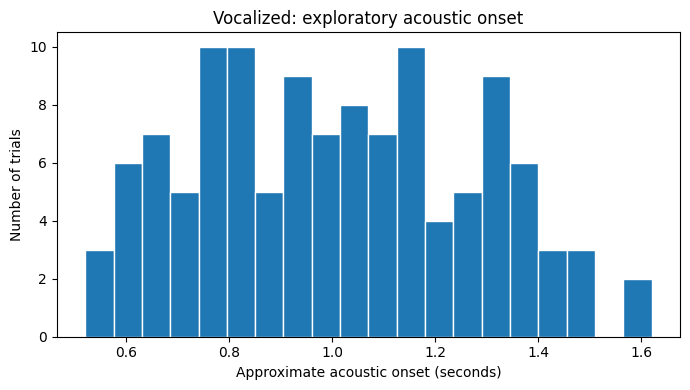


===== 최종 확인 =====
원본 음성 분석: 완료
BIDS 채널 파일: 6
BIDS 전극 파일: 2
BIDS 이벤트 파일: 6

✅ 22~24단계 실행 완료
기존 RSA 결과는 수정하지 않았습니다.


In [ ]:
import io
import re
import json
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from urllib.parse import quote
from scipy.io import wavfile

META_DIR = ANNOT_DIR / "nemar_metadata"
META_DIR.mkdir(parents=True, exist_ok=True)

# ==================================================
# STEP 22. 공개 BIDS 메타데이터 탐색
# ==================================================

OWNER = "nemarDatasets"
REPO = "nm000251"
BRANCH = "main"

TREE_FILE = META_DIR / "github_tree.json"

if TREE_FILE.exists():
    print("✅ 저장된 NEMAR 파일 목록 재사용")
    tree_info = json.loads(
        TREE_FILE.read_text(encoding="utf-8")
    )

else:
    print("NEMAR 파일 목록 확인 중...")

    api_url = (
        f"https://api.github.com/repos/"
        f"{OWNER}/{REPO}/git/trees/"
        f"{BRANCH}?recursive=1"
    )

    try:
        response = requests.get(
            api_url,
            headers={
                "Accept": "application/vnd.github+json"
            },
            timeout=40
        )

        response.raise_for_status()
        tree_info = response.json()

        TREE_FILE.write_text(
            json.dumps(tree_info, indent=2),
            encoding="utf-8"
        )

        print("✅ 공개 파일 목록 확보")

    except Exception as e:
        print("⚠️ 공개 파일 목록 요청 실패:", str(e))
        tree_info = {"tree": []}

files = [
    obj for obj in tree_info.get("tree", [])
    if obj.get("type") == "blob"
]

print("공개 저장소 파일 수:", len(files))

if tree_info.get("truncated"):
    print("⚠️ GitHub 파일 목록이 일부 생략됐습니다.")


# ==================================================
# STEP 23-A. 채널·전극·자극 정보 목록
# ==================================================

def relevant_path(path):

    basename = Path(path).name.lower()

    if basename.endswith((
        "_channels.tsv",
        "_electrodes.tsv",
        "_coordsystem.json",
        "_events.tsv"
    )):
        return True

    if path.startswith("code/") and path.endswith(
        (".py", ".csv", ".tsv", ".json")
    ):
        return True

    if path.startswith("stimuli/") and path.endswith(
        (".csv", ".tsv", ".json", ".txt")
    ):
        return True

    return False


candidates = [
    obj for obj in files
    if relevant_path(obj["path"])
]

print("\n===== 공개 메타데이터 후보 =====")

candidate_df = pd.DataFrame([
    {
        "path": obj["path"],
        "size_bytes": obj.get("size", 0)
    }
    for obj in candidates
])

if len(candidate_df):
    display(candidate_df)
else:
    print("메타데이터 후보를 확인하지 못했습니다.")


# ==================================================
# STEP 23-B. 작은 메타데이터만 다운로드
# ==================================================

downloaded = []

for obj in candidates:

    path = obj["path"]
    size = obj.get("size", 0)

    # 300KB를 초과하는 파일은 자동 다운로드하지 않음
    if size > 300_000:
        continue

    local = META_DIR / path.replace("/", "__")

    if local.exists():
        downloaded.append(local)
        continue

    raw_url = (
        f"https://raw.githubusercontent.com/"
        f"{OWNER}/{REPO}/{BRANCH}/"
        f"{quote(path, safe='/')}"
    )

    try:
        response = requests.get(
            raw_url, timeout=25
        )
        response.raise_for_status()

        # Git LFS / git-annex 포인터 등은 별도 확인
        local.write_bytes(response.content)
        downloaded.append(local)

    except Exception as e:
        print(
            "메타데이터 요청 실패:",
            path,
            str(e)[:120]
        )

print("\n✅ 확인 가능한 소형 메타데이터:", len(downloaded))


# ==================================================
# STEP 23-C. BIDS 채널 정보 확인
# ==================================================

channel_files = [
    p for p in downloaded
    if p.name.endswith("_channels.tsv")
]

print("\n===== BIDS 채널 정보 =====")

if not channel_files:

    print("채널 메타데이터 파일을 확보하지 못했습니다.")

else:

    for path in channel_files[:3]:

        try:
            channels = pd.read_csv(
                path, sep="\t"
            )

            print("\n파일:", path.name)
            print("행 수:", len(channels))
            print("열:", channels.columns.tolist())

            display(channels.head(12))

        except Exception as e:
            print(
                "파일 해석 실패:",
                path.name,
                str(e)
            )


electrode_files = [
    p for p in downloaded
    if p.name.endswith("_electrodes.tsv")
]

print("\n===== BIDS 전극 좌표 정보 =====")

if not electrode_files:

    print("BIDS 전극 좌표 파일을 확보하지 못했습니다.")

else:

    for path in electrode_files[:2]:

        try:
            electrodes = pd.read_csv(
                path, sep="\t"
            )

            print("\n파일:", path.name)
            print("행 수:", len(electrodes))
            print("열:", electrodes.columns.tolist())

            display(electrodes.head(12))

        except Exception as e:
            print(
                "파일 해석 실패:",
                path.name,
                str(e)
            )


event_files = [
    p for p in downloaded
    if p.name.endswith("_events.tsv")
]

print("\n===== 자극 시점 정보 =====")

if not event_files:

    print("자극 시점 파일을 확보하지 못했습니다.")

else:

    for path in event_files[:3]:

        try:
            events = pd.read_csv(
                path, sep="\t"
            )

            print("\n파일:", path.name)
            print("이벤트 수:", len(events))
            print("열:", events.columns.tolist())

            display(events.head(8))

        except Exception as e:
            print(
                "파일 해석 실패:",
                path.name,
                str(e)
            )


# ==================================================
# STEP 24-A. 실제 발화 음성 119개 검사
# ==================================================

AUDIO_ZIP = (
    DATA_DIR / "Original_Audio_Word.zip"
)

AUDIO_CSV = (
    RESULT_DIR / "audio_timing_audit.csv"
)

if AUDIO_CSV.exists():

    print("\n✅ 기존 음성 타이밍 검사 재사용")
    audio_df = pd.read_csv(AUDIO_CSV)

elif AUDIO_ZIP.exists():

    print("\n실제 발화 음성 파일 검사 중...")

    audio_rows = []

    with zipfile.ZipFile(AUDIO_ZIP) as z:

        wav_names = sorted([
            name for name in z.namelist()
            if name.lower().endswith(".wav")
        ])

        print("WAV 파일 수:", len(wav_names))

        for name in wav_names:

            try:

                sr, signal = wavfile.read(
                    io.BytesIO(z.read(name))
                )

                signal = signal.astype(np.float64)

                if signal.ndim == 2:
                    signal = signal.mean(axis=1)

                duration = len(signal) / sr

                # 20ms 단위 음향 에너지 계산
                frame = max(
                    1, int(sr * 0.02)
                )

                n_frames = len(signal) // frame

                if n_frames < 5:
                    continue

                trimmed = signal[:n_frames * frame]

                rms = np.sqrt(
                    np.mean(
                        trimmed.reshape(
                            n_frames, frame
                        ) ** 2,
                        axis=1
                    )
                )

                # 녹음별 음향 에너지 분포 기반
                # 매우 대략적인 발화 시작 후보
                background = np.percentile(rms, 20)
                peak = rms.max()

                threshold = max(
                    background * 2.5,
                    peak * 0.18
                )

                active = rms >= threshold

                # 연속해서 2프레임 이상 활동
                sustained = (
                    active[:-1] & active[1:]
                )

                indices = np.where(sustained)[0]

                onset = (
                    indices[0] * 0.02
                    if len(indices)
                    else np.nan
                )

                audio_rows.append({
                    "filename": Path(name).name,
                    "sample_rate": sr,
                    "duration_seconds": duration,
                    "onset_proxy_seconds": onset,
                    "peak_rms": peak
                })

            except Exception as e:
                print(
                    "WAV 검사 실패:",
                    name,
                    str(e)[:100]
                )

    audio_df = pd.DataFrame(audio_rows)

    audio_df.to_csv(
        AUDIO_CSV, index=False
    )

else:

    print("⚠️ 원본 음성 ZIP이 없습니다.")
    audio_df = pd.DataFrame()


# ==================================================
# STEP 24-B. 음성 타이밍 결과
# ==================================================

if not audio_df.empty:

    print("\n===== 음성 파일 기본 정보 =====")

    print("분석된 WAV:", len(audio_df))

    print(
        "\n파일 길이(초):"
    )

    display(
        audio_df[
            ["duration_seconds",
             "onset_proxy_seconds"]
        ].describe().round(3)
    )

    print("\n===== 앞 15개 파일 =====")

    display(
        audio_df[
            ["filename",
             "duration_seconds",
             "onset_proxy_seconds"]
        ].head(15).round(3)
    )

    plt.figure(figsize=(7, 4))

    vals = audio_df[
        "onset_proxy_seconds"
    ].dropna()

    plt.hist(
        vals,
        bins=20,
        edgecolor="white"
    )

    plt.xlabel(
        "Approximate acoustic onset (seconds)"
    )

    plt.ylabel("Number of trials")
    plt.title(
        "Vocalized: exploratory acoustic onset"
    )

    plt.tight_layout()

    plt.savefig(
        RESULT_DIR /
        "vocalized_audio_onset_audit.png",
        dpi=160
    )

    plt.show()
    plt.close()


print("\n===== 최종 확인 =====")

print(
    "원본 음성 분석:",
    "완료" if not audio_df.empty else "미완료"
)

print(
    "BIDS 채널 파일:",
    len(channel_files)
)

print(
    "BIDS 전극 파일:",
    len(electrode_files)
)

print(
    "BIDS 이벤트 파일:",
    len(event_files)
)

print("\n✅ 22~24단계 실행 완료")
print("기존 RSA 결과는 수정하지 않았습니다.")